# Cartoon subfigures

Here, we make several cartoon items for figures 1 and the cartoon of smc abc. 

figure 1 cartoons:
 * inter-individual heterogeneity of cell shape and how it might affect transcriptional dynamics
 * temporal heterogeniety
 * spatial heterogeneity
 * Lotka volterra ii het across time series replicates

 figure X cartoon minibatch SMC ABC:
 * Point cloud dataset of like 30 points (The dataset)
 * (Point cloud of selected vs non-selected points colored and marked)
 * Point cloud dataset of jittered sample (simulated data) with lined connecting them with observed data representing distance
 * PDF of a Gaussian at a few different sampling sizes with a fixed xlim and ylim
 * 

In [1]:
import numpy as np
from matplotlib import pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: 'figures/cartoon_pointcloud.svg'

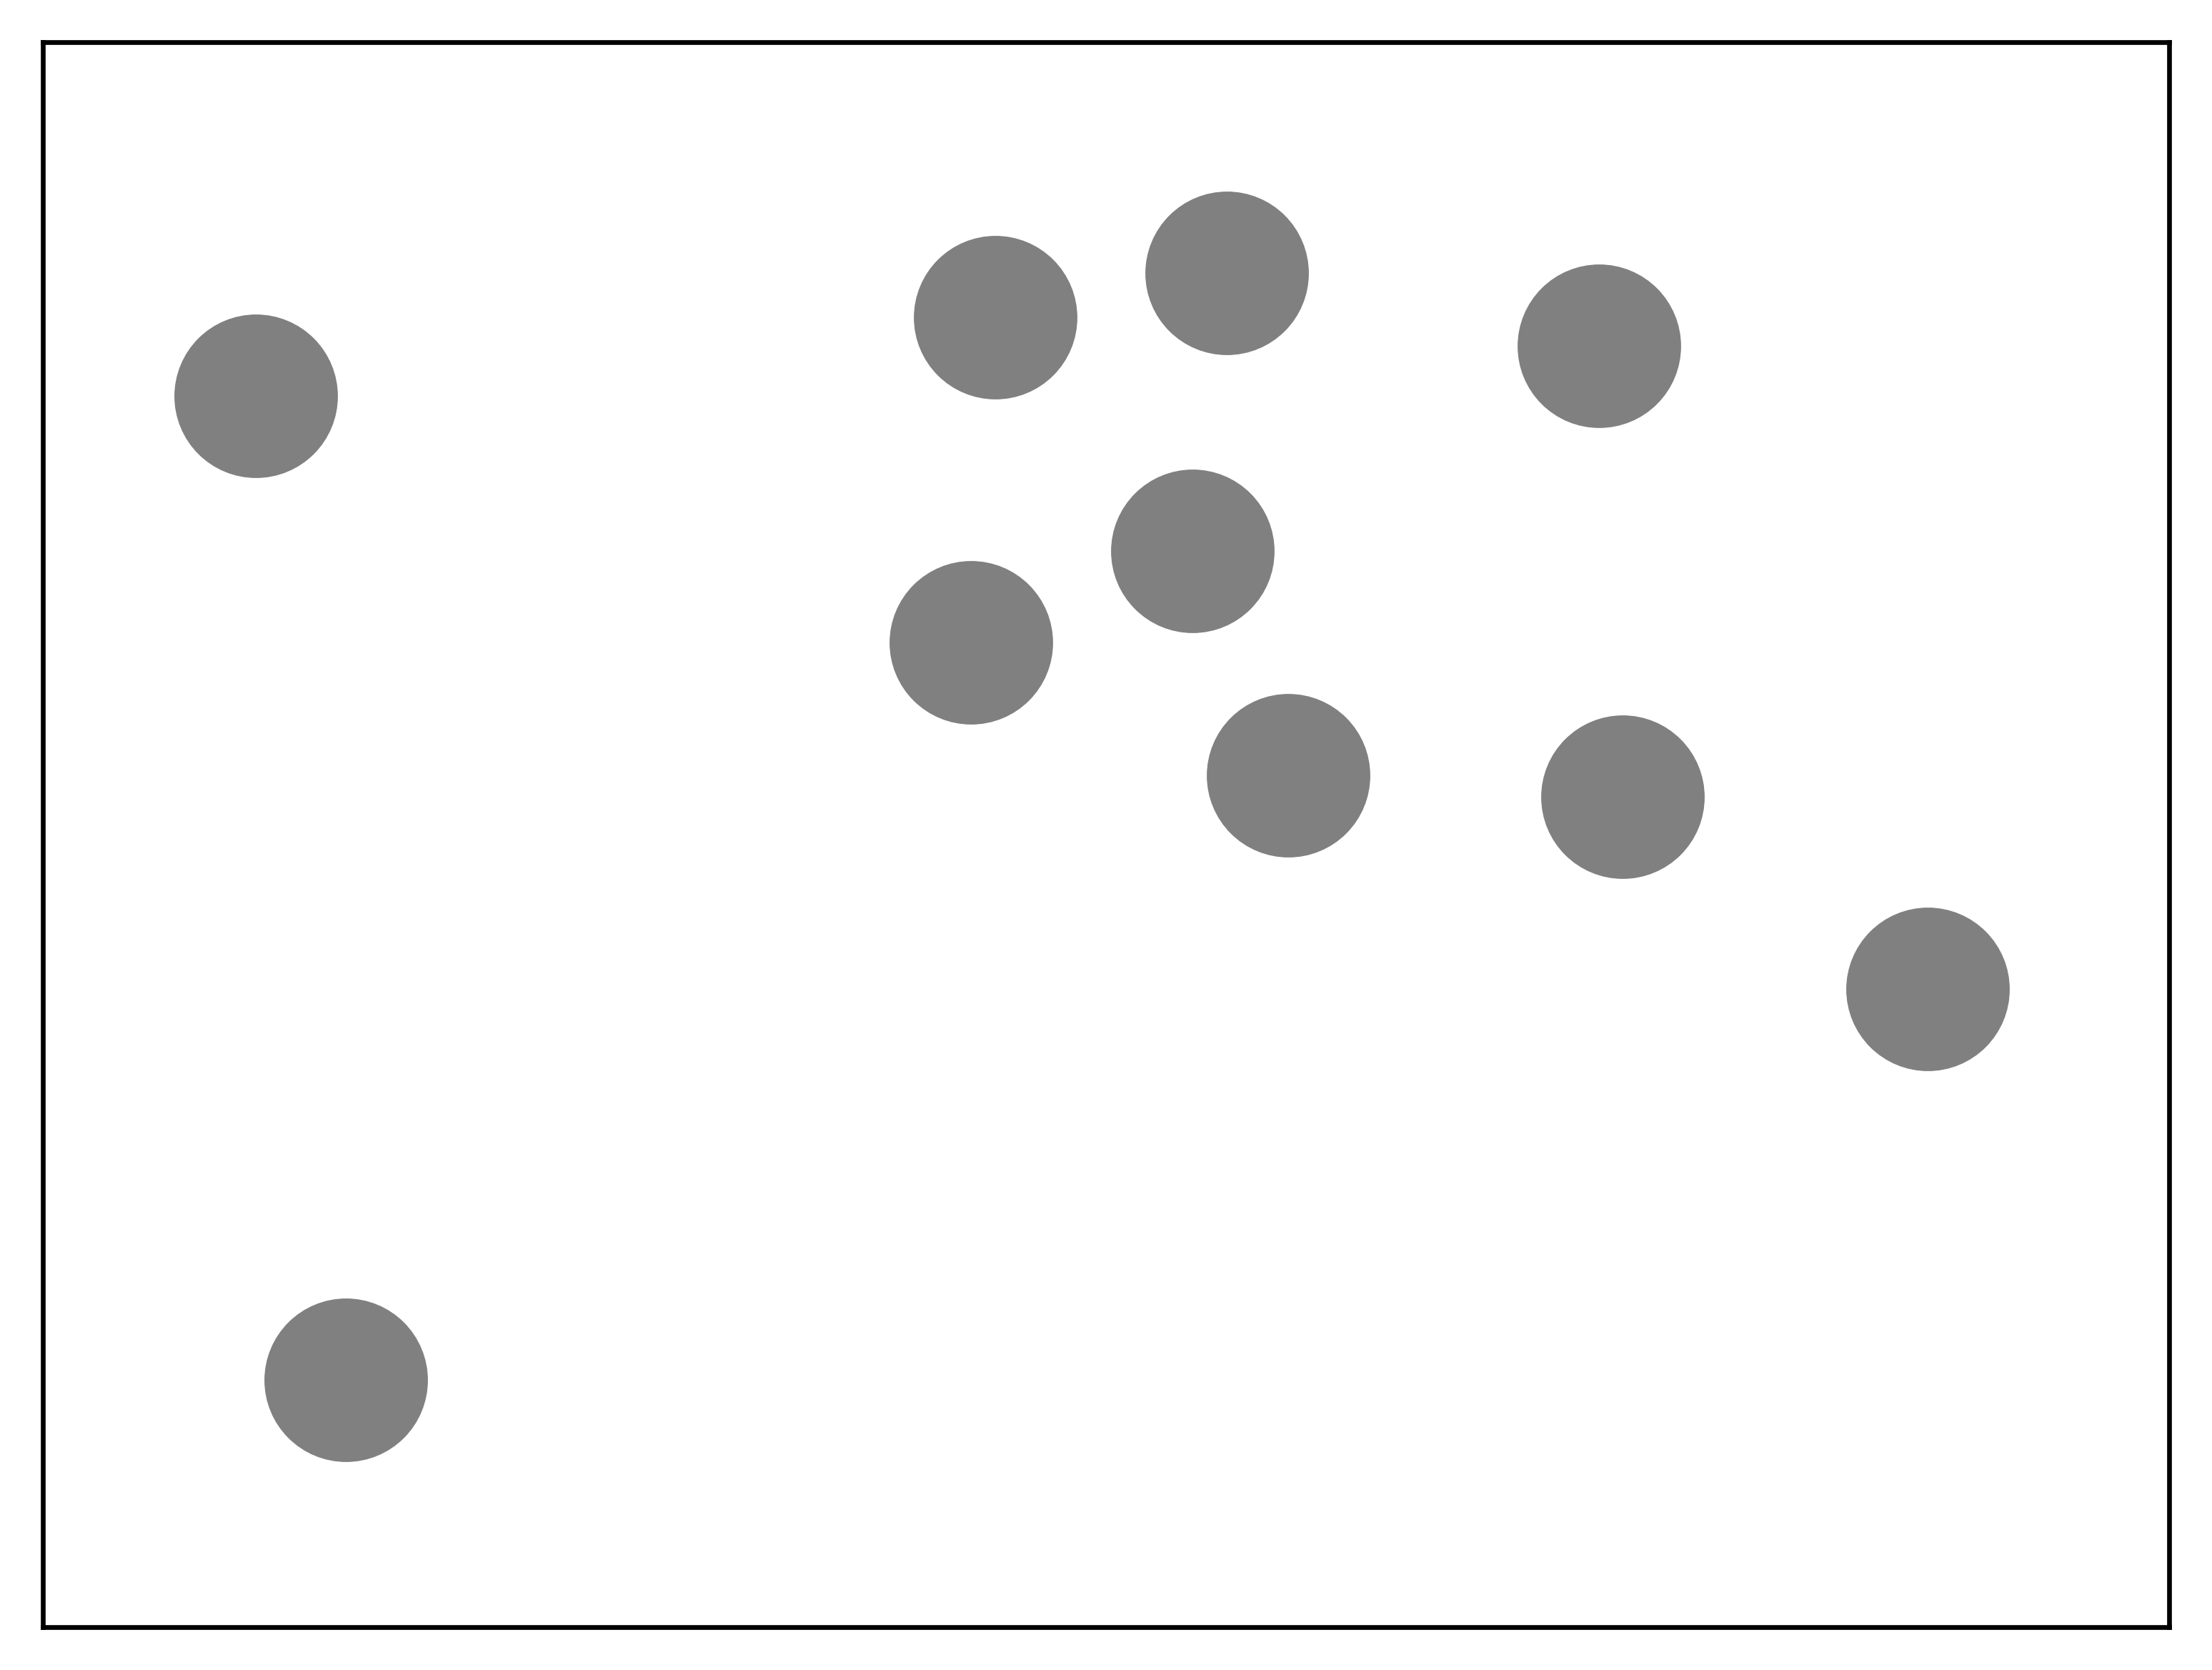

In [4]:
## Dataset and sampling
np.random.seed(0)
n = 10
wsize = (-0.1,1.1)
msize = 700
header = 'figures/cartoon_pointcloud_'

z = np.random.uniform(0,1,size = (n,2))
x = z[:,0]
y = z[:,1]

const_bs = 3
#batch_sizes = [const_bs,const_bs,const_bs,const_bs,2*const_bs, int(0.8*n)]
batch_size = [5]
#batches_cmb = [np.random.choice(n,size = (1,b),replace = False) for b in batch_sizes]
batches_cmb = [np.random.choice(n,size = (1,batch_size[0]),replace = False)]

fig,ax = plt.subplots()
ax.scatter(x=x,y=y,marker = 'o', s = msize,color = 'gray')
plt.xlim(wsize)
plt.ylim(wsize)
plt.xticks([]);
plt.yticks([]);
fig.savefig(
    'figures/cartoon_pointcloud.svg',
    format="svg",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)


for i,batch in enumerate(batches_cmb):
    fig,ax = plt.subplots()
    x_ = np.delete(x,batch)
    y_ = np.delete(y,batch)
    ax.scatter(x=x_,y=y_,marker = 'o', s = msize,color = 'gray')
    ax.scatter(x=x[batch],y=y[batch],marker = 'o', s = msize,color = 'blue')
    plt.xlim(wsize)
    plt.ylim(wsize)
    plt.xticks([]);
    plt.yticks([]);

    filename = header + "n" + str(batch.shape[1]) + "_iter" + str(i) + '.svg'
    print(filename)
    fig.savefig(
        filename,
        format="svg",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

figures/cartoon_sim_n5_iter0.svg


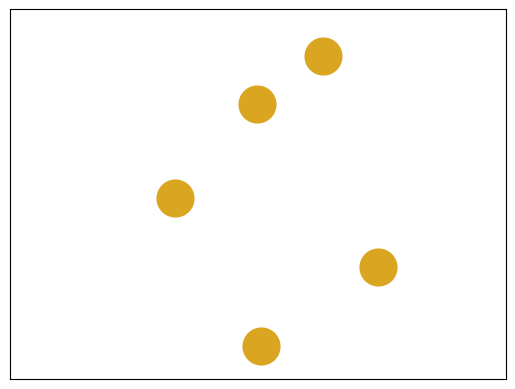

In [ ]:
### Simulations
header = 'figures/cartoon_sim_'
np.random.seed(11)
sigma = 0.25
for i,batch in enumerate(batches_cmb):
    fig,ax = plt.subplots()
    x_ = x[batch]
    y_ = y[batch]
    #ax.scatter(x_,y_,marker = 'o',s = msize, color = 'blue')
    #ax.scatter(np.delete(x,batch),np.delete(y,batch),marker = 'o', s = msize,color = 'lightgray')
    px = np.random.normal(0,sigma,size = batch.shape[1])
    py = np.random.normal(0,sigma,size = batch.shape[1])
    ax.scatter(x_ + px, y_ + py,marker = 'o',s=msize,color = 'goldenrod')
    #ax.plot(np.vstack((x_,x_ + px)),np.vstack((y_,y_ + py)), color = 'black',linewidth = 3,zorder = -1)
    plt.xlim(wsize)
    plt.ylim(wsize)
    
    plt.xticks([]);
    plt.yticks([]);
    filename = header + "n" + str(batch.shape[1]) + "_iter" + str(i) + '.svg'
    print(filename)
    fig.savefig(
        filename,
        format="svg",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

figures/cartoon_dist_n5_iter0.svg


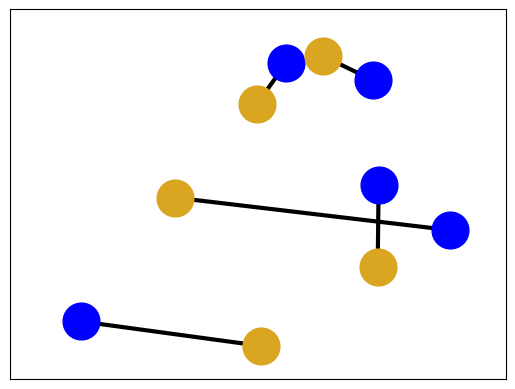

In [ ]:
### Simulations
header = 'figures/cartoon_dist_'
np.random.seed(11)
sigma = 0.25
for i,batch in enumerate(batches_cmb):
    fig,ax = plt.subplots()
    x_ = x[batch]
    y_ = y[batch]
    ax.scatter(x_,y_,marker = 'o',s = msize, color = 'blue')
    #ax.scatter(np.delete(x,batch),np.delete(y,batch),marker = 'o', s = msize,color = 'lightgray')
    px = np.random.normal(0,sigma,size = batch.shape[1])
    py = np.random.normal(0,sigma,size = batch.shape[1])
    ax.scatter(x_ + px, y_ + py,marker = 'o',s=msize,color = 'goldenrod')
    ax.plot(np.vstack((x_,x_ + px)),np.vstack((y_,y_ + py)), color = 'black',linewidth = 3,zorder = -1)
    plt.xlim(wsize)
    plt.ylim(wsize)
    
    plt.xticks([]);
    plt.yticks([]);
    filename = header + "n" + str(batch.shape[1]) + "_iter" + str(i) + '.svg'
    print(filename)
    fig.savefig(
        filename,
        format="svg",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )
    

figures/cartoon_deltadensity_full.svg


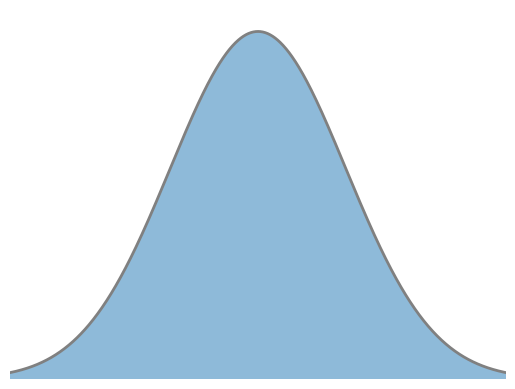

In [ ]:
header = 'figures/cartoon_deltadensity_'

sigma = 0.05
def gauss(x,n):
    return np.exp(-0.5 * (x**2 / (sigma**2/n)))/np.sqrt(2*np.pi*(sigma**2/n))
x_gauss = np.linspace(-0.1,0.1,1000)

fig,ax = plt.subplots()
n = 2
y = gauss(x_gauss,n)
ax.plot(x_gauss,y,color = 'gray',linewidth = 2)
ax.fill_between(x_gauss,y,alpha = 0.5)
plt.xlim((-0.1,0.1))
plt.ylim((0,12))
ax.axis('off')


filename = header + 'full.svg'
print(filename)
fig.savefig(
    filename,
    format="svg",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

figures/cartoon_deltadensity_eps.svg


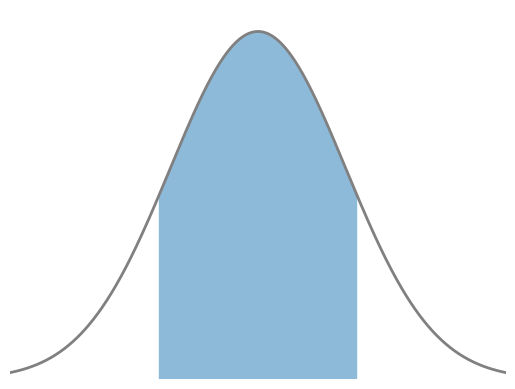

In [ ]:
fig,ax = plt.subplots()
n = 2
y = gauss(x_gauss,n)
width = 0.04
xe = np.linspace(-width,width,500)
ye = gauss(xe,n)
ax.plot(x_gauss,y,color = 'gray',linewidth = 2)
ax.fill_between(xe,ye,alpha = 0.5)
plt.xlim((-0.1,0.1))
plt.ylim((0,12))
ax.axis('off')

filename = header + 'eps.svg'
print(filename)
fig.savefig(
    filename,
    format="svg",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

(np.float64(-0.1), np.float64(0.1), np.float64(0.0), np.float64(12.0))

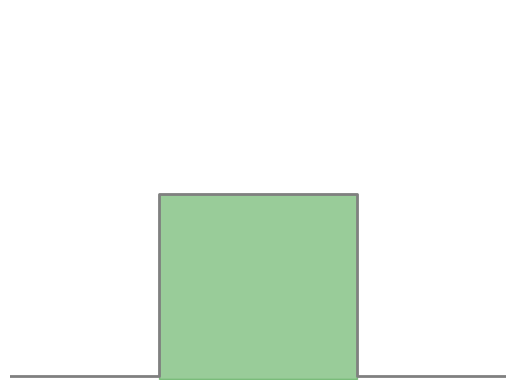

In [ ]:
fig,ax = plt.subplots()
xrange = 0.04
ax.plot([-0.1,-xrange,-xrange,xrange,xrange,0.1], [0.1,0.1,6,6,0.1,0.1],color = 'gray',linewidth = 2)
ax.fill_between([-xrange,xrange],[6,6],color = 'green',alpha = 0.4)
plt.xlim((-0.1,0.1))
plt.ylim((0,12))
ax.axis('off')

figures/cartoon_deltadensity_n3_eps0.018.svg
figures/cartoon_deltadensity_n3_eps0.055.svg
figures/cartoon_deltadensity_n3_eps0.07.svg
figures/cartoon_deltadensity_n6_eps0.018.svg
figures/cartoon_deltadensity_n6_eps0.055.svg
figures/cartoon_deltadensity_n6_eps0.07.svg
figures/cartoon_deltadensity_n24_eps0.018.svg
figures/cartoon_deltadensity_n24_eps0.055.svg
figures/cartoon_deltadensity_n24_eps0.07.svg


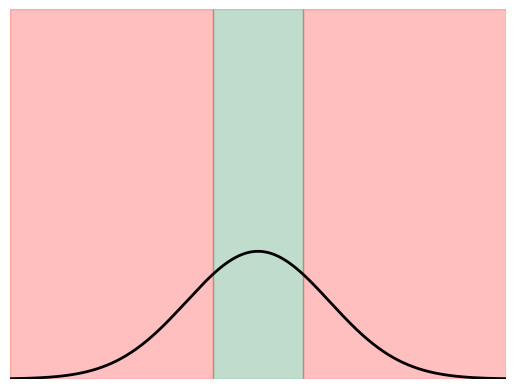

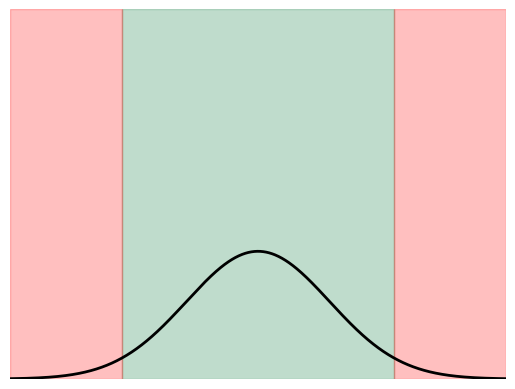

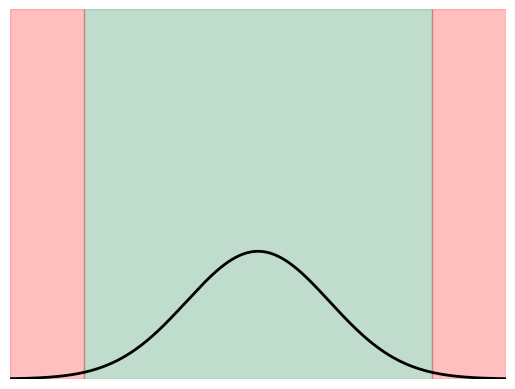

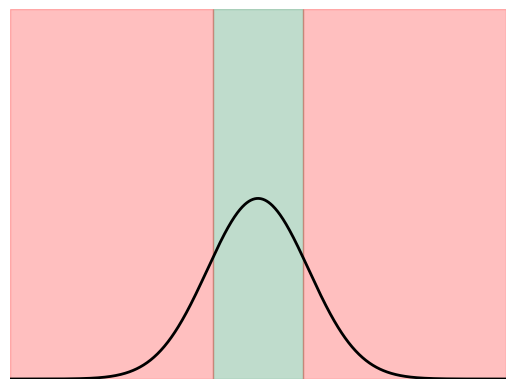

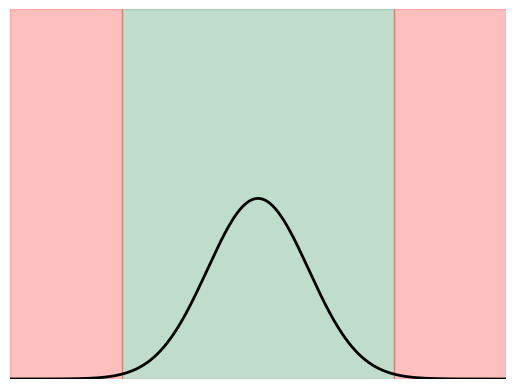

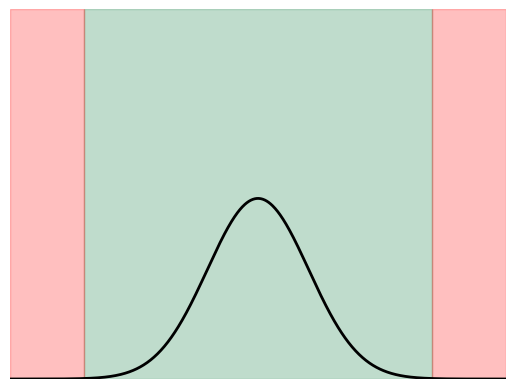

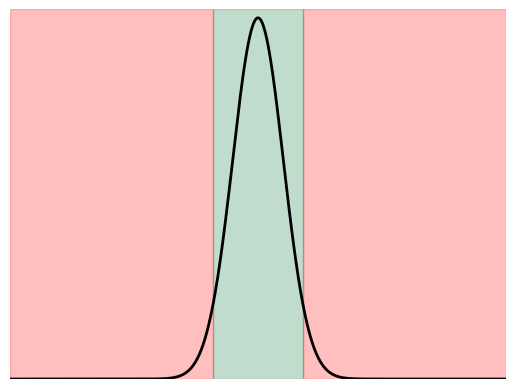

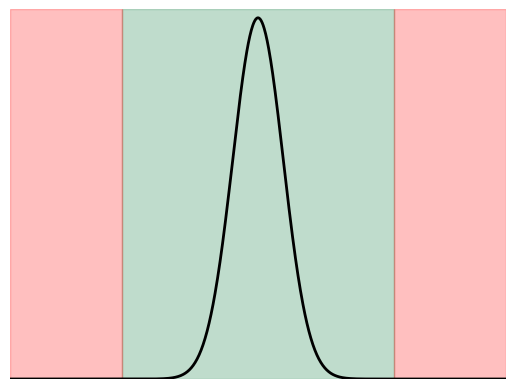

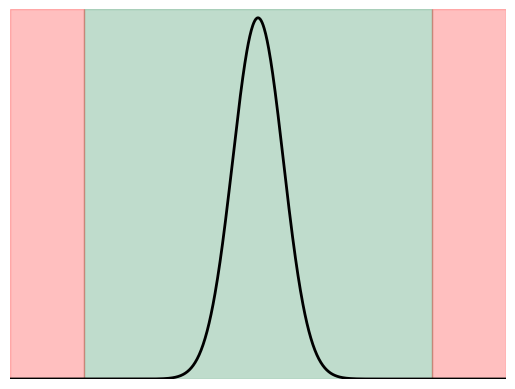

In [ ]:
### 
header = 'figures/cartoon_deltadensity_'

sigma = 0.05
def gauss(x,n):
    return np.exp(-0.5 * (x**2 / (sigma**2/n)))/np.sqrt(2*np.pi*(sigma**2/n))
x_gauss = np.linspace(-0.1,0.1,1000)

for n in [3,6,24]:
    for e in [0.018,0.055,0.07]:
        fig,ax = plt.subplots()
        ax.plot(x_gauss,gauss(x_gauss,n),color = 'black',linewidth = 2)
        ax.axvspan(-e,e,color ='seagreen',alpha = 0.3)
        ax.axvspan(-0.1,-e,color = 'red',alpha = 0.25)
        ax.axvspan(e,0.1,color = 'red',alpha = 0.25)
        plt.xlim((-0.1,0.1))
        plt.ylim((0,40))
        ax.axis('off')
        filename = header + "n" + str(n) + "_eps" + str(e) + '.svg'
        print(filename)
        fig.savefig(
            filename,
            format="svg",
            dpi=600,
            bbox_inches="tight",
            transparent=True
        )

figures/cartoon_posterior_n0.svg
figures/cartoon_posterior_n1.svg
figures/cartoon_posterior_n2.svg
figures/cartoon_posterior_n3.svg


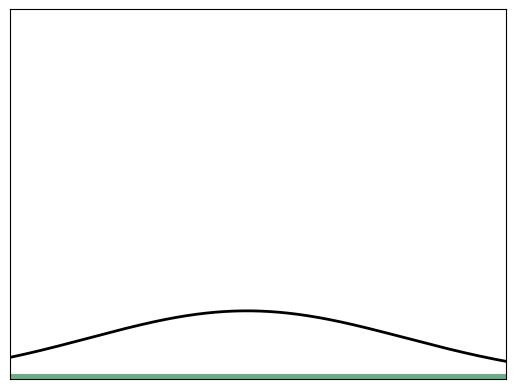

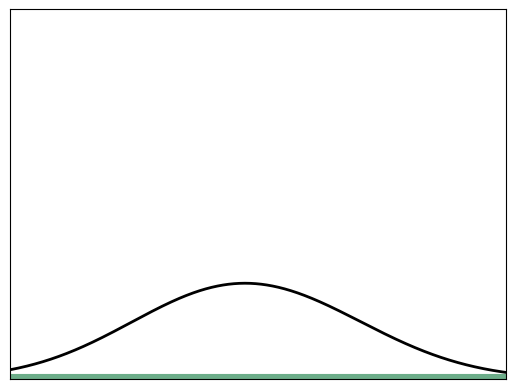

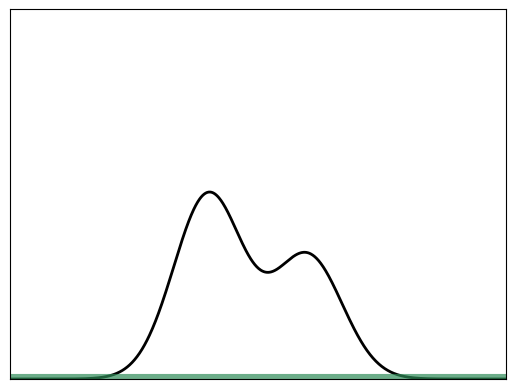

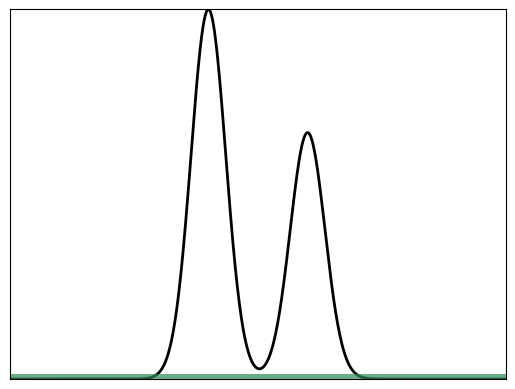

In [ ]:
## Posterior
#Maybe something multimodal. Then add some whitening for small sample sizes
def posterior(x,c1 = -2,c2 = 2,s1=0.6,s2 = 0.6,w = 0.6):
    g1 = np.exp(-0.5 * (x-c1)**2 / s1**2) / np.sqrt(2*np.pi*s1**2)
    g2 = np.exp(-0.5 * (x-c2)**2 / s2**2) / np.sqrt(2*np.pi*s2**2)
    out = w*g1 + (1-w)*g2
    return out
xrange = 10
grid = np.linspace(-xrange,xrange,1000)

header = 'figures/cartoon_posterior_'
ymax = np.max(posterior(grid,s1 = 0.7,s2 = 0.7))

for i,s in enumerate([6,4,1.4,0.7]):
    fig,ax = plt.subplots()
    ax.plot(grid,posterior(grid, s1 = s,s2 = s),linewidth = 2, color = 'black')
    ylim = ax.get_ylim()
    xlim = ax.get_xlim()
    #ax.axvspan(xlim[0],xlim[1],0,ylim[1]*0.1,color = 'seagreen', alpha = 1)
    plt.plot([-xrange,xrange],[0,0],color = 'seagreen',linewidth = 8,alpha = 0.7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([-xrange,xrange])
    ax.set_ylim([0,ymax])
    filename = header + "n" + str(i) + '.svg'
    print(filename)
    fig.savefig(
        filename,
        format="svg",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )
        

figures/cartoon_proposal_n0.svg
figures/cartoon_proposal_n1.svg
figures/cartoon_proposal_n2.svg


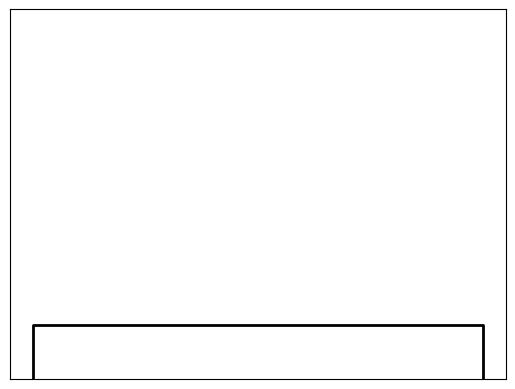

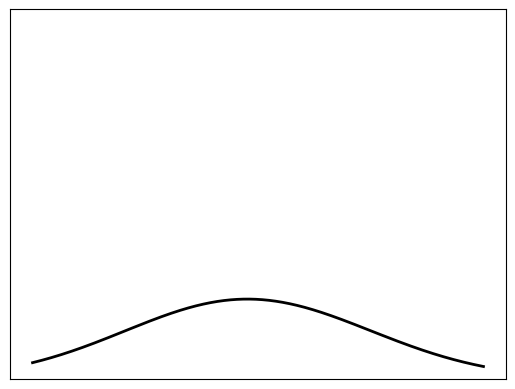

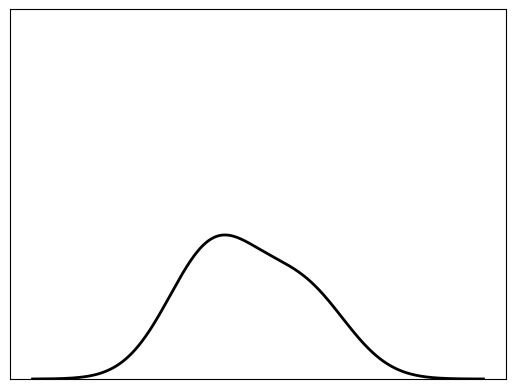

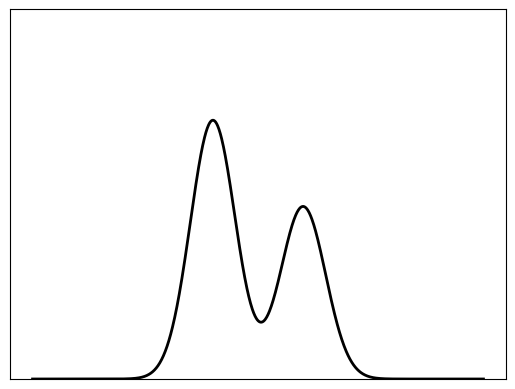

In [ ]:

def proposal(x,c1 = -2,c2 = 2,s1=0.6,s2 = 0.6,w = 0.6):
    g1 = np.exp(-0.5 * (x-c1)**2 / s1**2) / np.sqrt(2*np.pi*s1**2)
    g2 = np.exp(-0.5 * (x-c2)**2 / s2**2) / np.sqrt(2*np.pi*s2**2)
    out = w*g1 + (1-w)*g2
    return out
xrange = 10
grid = np.linspace(-xrange,xrange,1000)

header = 'figures/cartoon_proposal_'

fig,ax = plt.subplots()
ax.plot([-xrange,-xrange,xrange,xrange], [0,1/20,1/20,0],color = 'black',linewidth = 2)
ax.set_ylim([0,ymax])
ax.set_xticks([])
ax.set_yticks([])
fig.savefig(
    'figures/cartoon_proposal_prior.svg',
    format="svg",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)
for i,s in enumerate([5,2,1]):
    fig,ax = plt.subplots()
    ax.plot(grid,posterior(grid, s1 = s,s2 = s),linewidth = 2, color = 'black')
    ax.set_ylim([0,ymax])
    ax.set_xticks([])
    ax.set_yticks([])
    filename = header + "n" + str(i) + '.svg'
    print(filename)
    fig.savefig(
        filename,
        format="svg",
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )
        

# Cartoon: Figure 1

Here's my vision as subfigures:
1. Inter-individual heterogeneities (vs spatial vs temporal? Or as examples in those contexts)
2. spatial transcriptional dynamics as an example - cell shape heterogeneity as affecting TD (centered site, circular shape + combinations of perturbations. quantities to represent a certain indeterminacy. noting that area or surface area might oversimplify the data)
3. 

# Cartoon: supplementary material - plots of selection kernel

Top left - no sampling noise, indicator function, high abc threhsold

Top to bottom - increasing sampling noise

Left to right - decreasing epsilon

Arrows to depict those gradients. 

3 by 3

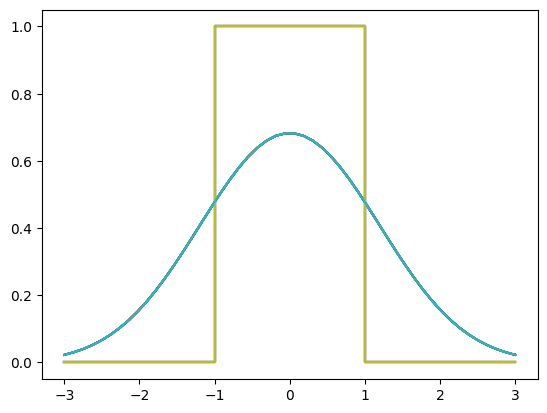

In [2]:
from scipy.stats import norm

n = 1


#Gaussian pdf
def pdf(x,s):
    return norm.pdf(x,scale = s)
def cdf(x):
    return norm.cdf(x)

def indicator(x,eps):
    xmin = np.min(x)
    xmax = np.max(x)
    xout = np.array([xmin,-eps,-eps,eps,eps,xmax])
    yout = np.array([0,0,1,1,0,0])
    return xout, yout
def rho(a,eps):
    return 2*cdf(2*a*eps)-1 - (pdf(0,1) - pdf(2*a*eps,1))/(a*eps)
def kernel(x,eps,a):
    return (cdf(a*(x + eps)) - cdf(a*(x - eps)))


fig,ax = plt.subplots()
for i in range(10):
    x = np.linspace(-3,3)
    plt.plot(*indicator(x,1))
    plt.plot(x,kernel(x,1,np.sqrt(n)))

In [3]:

def rho(a,eps):
    return 2*cdf(2*a*eps)-1 - (pdf(0,1) - pdf(2*a*eps,1))/(a*eps)
n = 1
print(rho(np.sqrt(n),0.1))
#print(rho2(np.sqrt(n),0.1))

0.07952355461843774


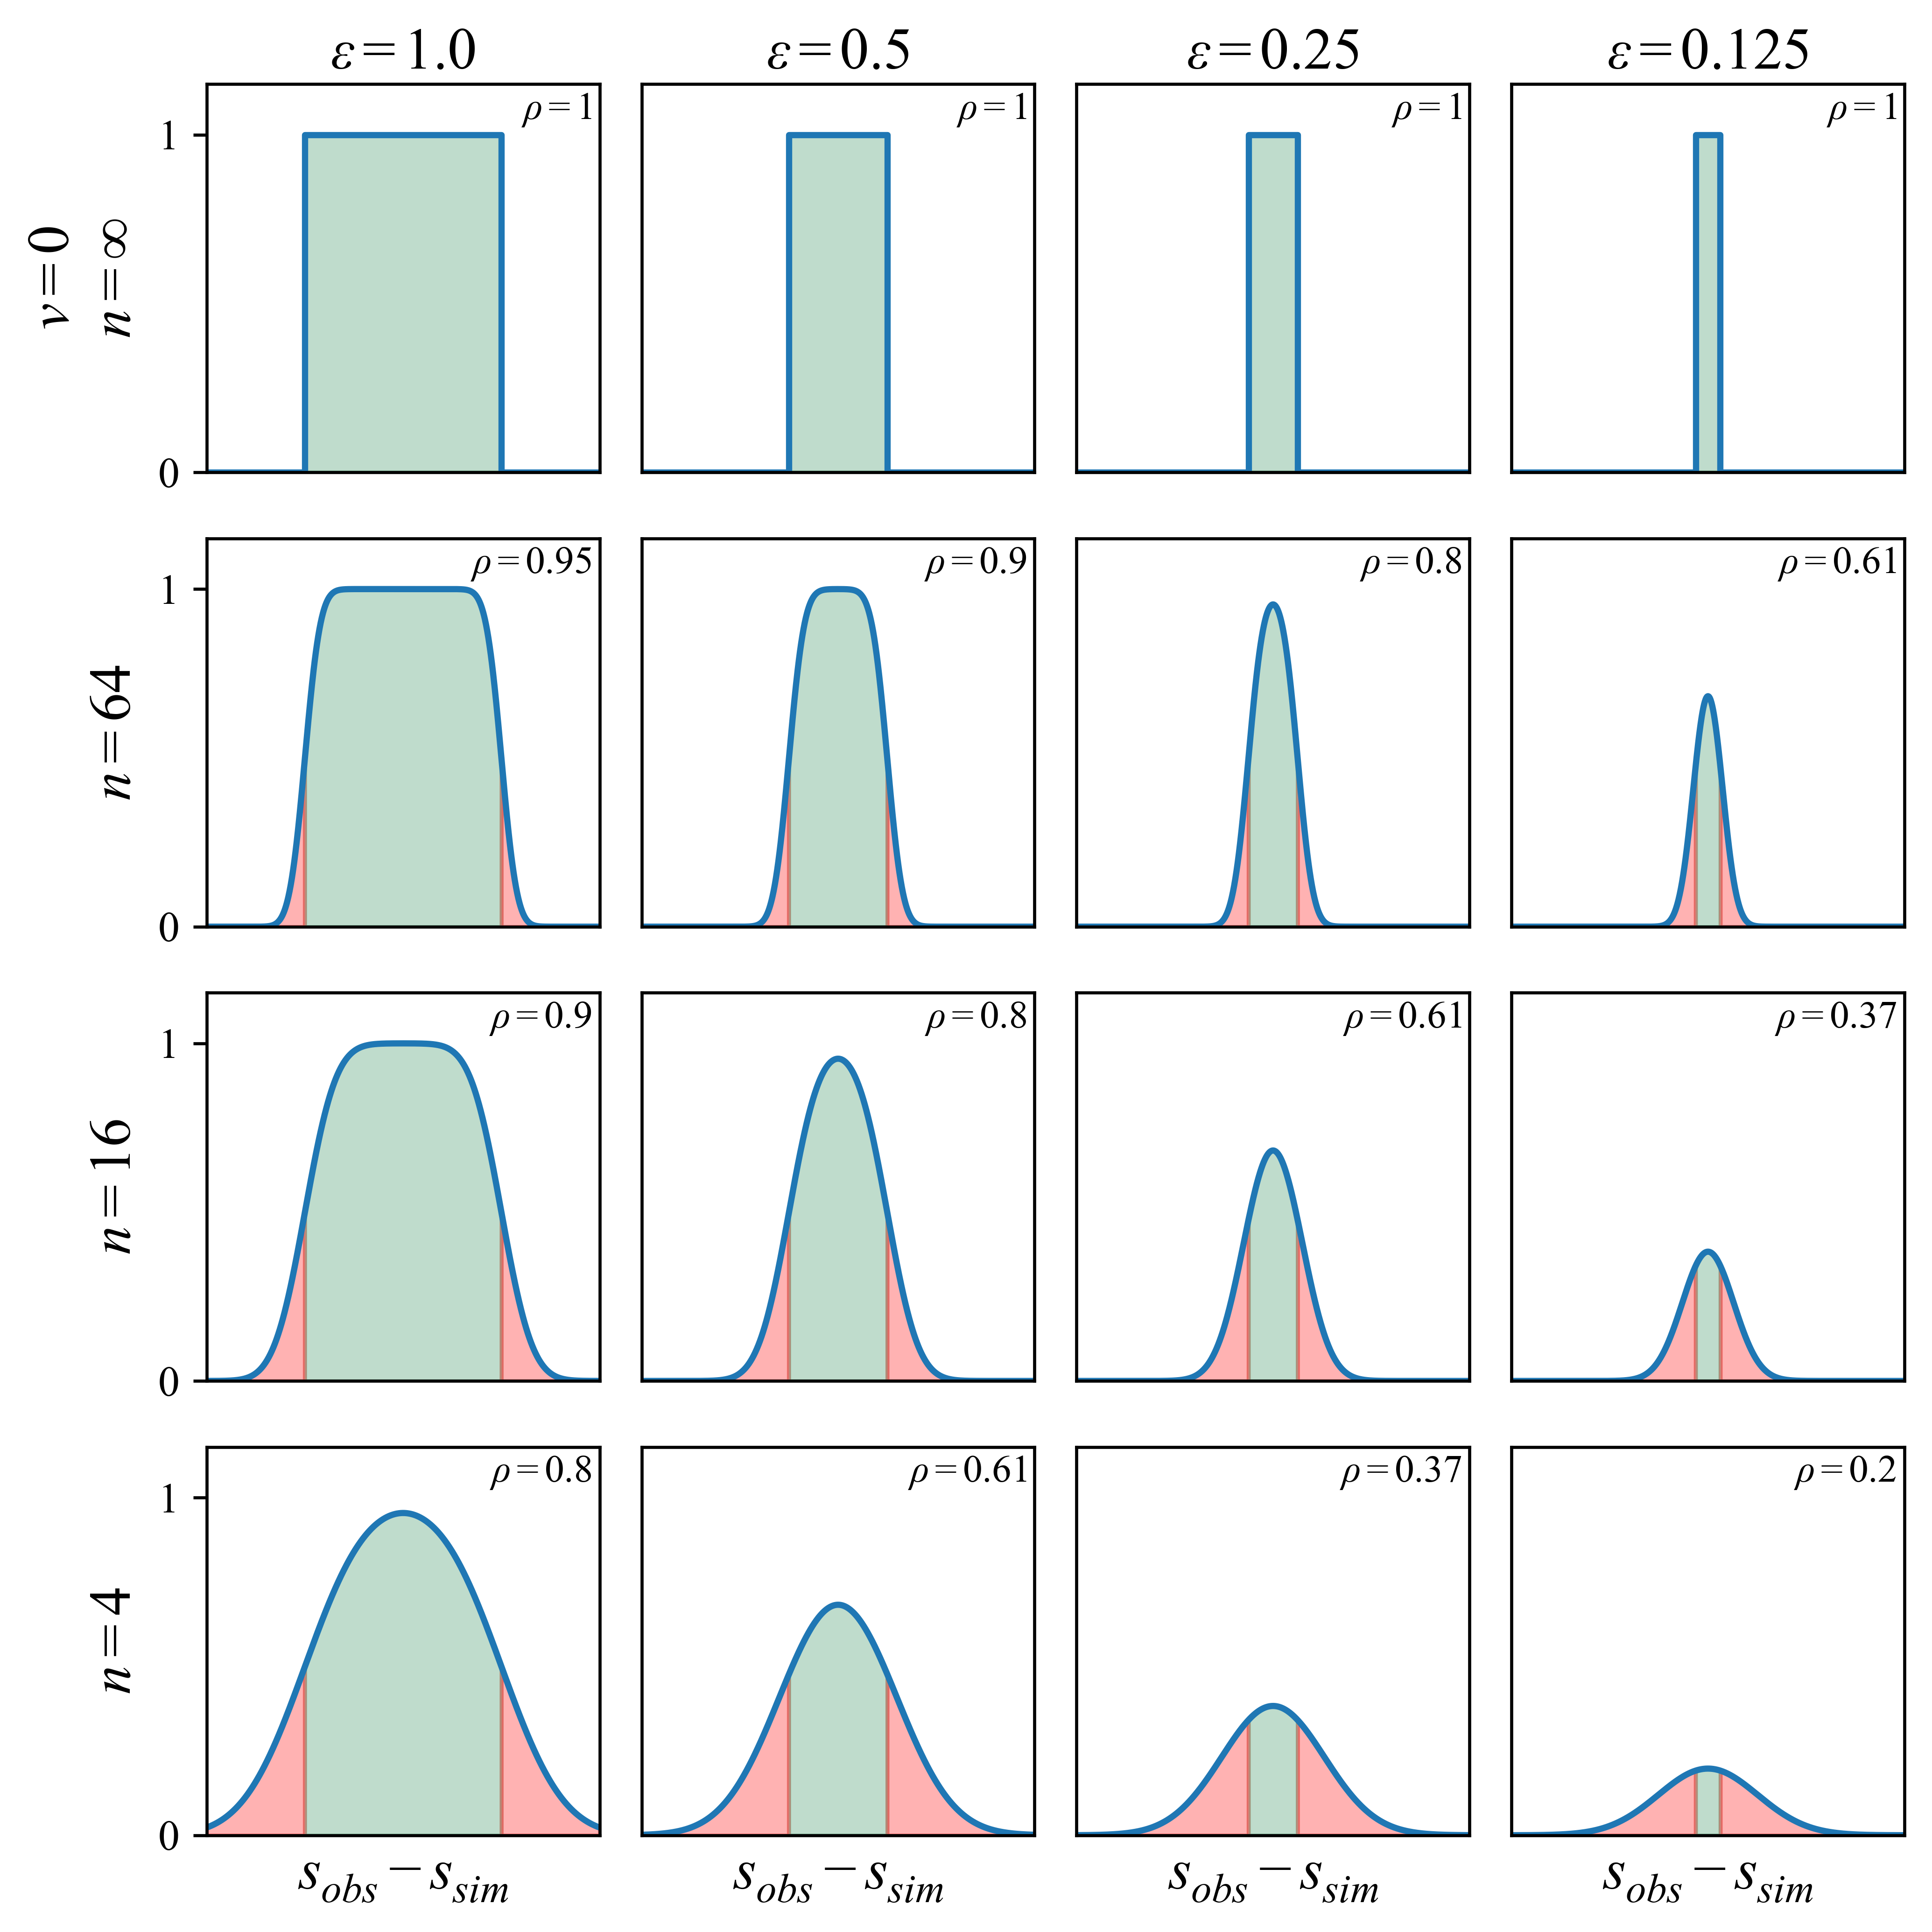

In [4]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
    'mathtext.sf': 'Times New Roman',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.title_fontsize': 10,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'lines.linewidth': 1.6,
    'lines.markersize': 8,
    'errorbar.capsize': 2.5,
    'svg.fonttype' : 'none',
    'svg.hashsalt' : '42',
})


fig,ax = plt.subplots(nrows = 4,ncols = 4,figsize = (7,7))


xrange = np.linspace(-2,2,1001)
eps = np.array([1,0.5,0.25,0.125])
sample_sizes = 1/eps**2
sample_sizes = np.array([1,64,16,4])
alist = np.sqrt(sample_sizes)


fs = 12

ylabs = [
    r"$v = 0$" "\n" r"$n = \infty$",
    r"$n = 64$",
    r"$n = 16$",
    r'$n = 4$'
]
xlab = r'$s_{obs} - s_{sim}$'


for i in range(4):
    for j in range(4):
        if i == 0:
            x,y = indicator(xrange,eps = eps[j])
        else:
            x = xrange
            y = kernel(xrange,eps[j],alist[i])

        ax[i,j].plot(x,y)
        ax[i,j].plot()

        #Ticks and labels
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].set_xlim((np.min(xrange),np.max(xrange)))
        if j == 0:
            ax[i,j].set_yticks([0,1])
            ax[i,j].set_ylabel(ylabs[i])
        if i == 0:
            ax[i,j].xaxis.set_label_position('top')
            ax[i,j].set_xlabel(rf"$ \epsilon = {eps[j]} $")
        if i == 3:
            ax[i,j].set_xlabel(xlab)
        p = 1 if (i == 0) else round(rho(alist[i],eps[j]),2)
        ax[i,j].text(0.98,0.98, rf"$ \rho = {p} $", transform=ax[i,j].transAxes,ha = 'right', va = 'top')
        ax[i,j].set_ylim((0,1.15))

        #Shade accept and reject regions
        mask = (x >= -eps[j]) & (x <= eps[j])
        ax[i,j].fill_between(x[mask],y[mask],color = 'seagreen',alpha = 0.3)
        mask = (x < -eps[j])
        ax[i,j].fill_between(x[mask],y[mask],color = 'red',alpha = 0.3)
        mask = (x >= eps[j])
        ax[i,j].fill_between(x[mask],y[mask],color = 'red',alpha = 0.3)

plt.tight_layout()

fig.savefig(
    '../figures/cartoon_selection_kernel.pdf',
    format="pdf",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)


# Figure 1: Heterogeneity

The figure depicts inter-individual heterogeneity, the primary concern of this paper. 

subfig A. should show the model of smFISh we're concerned with. The intensity of the model over an ideal domain with statistics. Below that, it's the effects of various domain shapes on the overall counts. 

subfig B. Shows the same thing for Lotka Volterra? 

subfig C. a few other examples of interindividual heterogeneity that aren't covered here. 

#### Cartoon of TD

Idea: Similar to the Kilic: Plot a time series of Poisson in time distribution with Poisson decay rates etc. Plot the burst sizes. Then plot an ideal cell with brownian motion trajectories. Describe the cells jumping over the boundaries. 

In [4]:
"""
2D Spatial stochastic model simulator with explicit event tracking.
Simulates transcriptional dynamics in a circular cell.
Tracks: births, deaths, exports, and particle trajectories in 2D.
"""

import numpy as np
from scipy.stats import gamma, expon
from dataclasses import dataclass
from typing import List as ListType, Tuple

@dataclass
class Particle:
    """Represents a single RNA molecule"""
    birth_time: float
    death_time: float  # None if still alive at end of sim
    export_time: float  # None if never exported
    trajectory: ListType[Tuple[float, float, float]]  # (time, x, y) pairs in 2D

class SpatialStochasticSimulator:
    """
    Simulates a 2D spatial stochastic model of transcriptional dynamics in a circular cell.
    
    Events:
    - Birth: Poisson process in time, with geometric burst sizes
    - Death: Exponential degradation
    - Export: Particle crosses cell boundary (Brownian motion in 2D)
    - Diffusion: Brownian motion in 2D within circular cell
    """
    
    def __init__(self, 
                 kplus: float,      # Birth rate (events per time)
                 kminus: float,     # Death rate (1/mean lifetime)
                 rburst: float,     # Mean burst size (geometric parameter)
                 D: float,          # Diffusion coefficient
                 cell_radius: float = 1.0,   # Cell radius (circular)
                 birth_site: Tuple[float, float] = None):  # Birth position (x, y) (default: center)
        
        self.kplus = kplus
        self.kminus = kminus
        self.rburst = rburst
        self.D = D
        self.cell_radius = cell_radius
        self.birth_site = birth_site if birth_site is not None else (0.0, 0.0)
        
        # Event lists
        self.birth_events = []      # (time, burst_size)
        self.particles: ListType[Particle] = []
        
    def simulate(self, T: float, dt: float = 0.001, seed: int = None):
        """
        Run simulation for time T with timestep dt in 2D circular cell.
        
        Parameters
        ----------
        T : float
            Total simulation time
        dt : float
            Diffusion timestep
        seed : int
            Random seed
        """
        if seed is not None:
            np.random.seed(seed)
        
        # Reset
        self.birth_events = []
        self.particles = []
        
        # Generate birth events (Poisson)
        num_birth_events = np.random.poisson(self.kplus * T)
        birth_times = np.sort(np.random.uniform(0, T, num_birth_events))
        
        # Generate burst sizes (Geometric)
        burst_sizes = np.random.geometric(1.0 / self.rburst, num_birth_events)
        
        self.birth_events = list(zip(birth_times, burst_sizes))
        
        # Create particles and track trajectories
        particle_id = 0
        for birth_time, burst_size in self.birth_events:
            for _ in range(int(burst_size)):
                # Initialize particle at birth site (center of cell)
                particle = Particle(
                    birth_time=birth_time,
                    death_time=None,
                    export_time=None,
                    trajectory=[(birth_time, self.birth_site[0], self.birth_site[1])]
                )
                
                # Determine death time
                death_time = birth_time + np.random.exponential(1.0 / self.kminus)
                if death_time < T:
                    particle.death_time = death_time
                
                # Diffuse particle in 2D
                self._diffuse_particle(particle, T, dt)
                
                self.particles.append(particle)
                particle_id += 1
    
    def _diffuse_particle(self, particle: Particle, T: float, dt: float):
        """Diffuse a particle in 2D and track trajectory until death/export/end."""
        time = particle.trajectory[-1][0]
        x = particle.trajectory[-1][1]
        y = particle.trajectory[-1][2]
        
        sqrt_2Ddt = np.sqrt(2.0 * self.D * dt)
        
        while time < T:
            if particle.death_time is not None and time >= particle.death_time:
                # Particle died
                break
            
            # Take 2D diffusion step
            time += dt
            x += np.random.normal(0, sqrt_2Ddt)
            y += np.random.normal(0, sqrt_2Ddt)
            
            # Check boundary (circular cell)
            distance_from_center = np.sqrt(x**2 + y**2)
            if distance_from_center > self.cell_radius:
                # Particle exported
                particle.export_time = time
                break
            
            # Clip to end of sim
            if time > T:
                time = T
            
            particle.trajectory.append((time, x, y))
    
    def get_birth_times_and_sizes(self):
        """Return arrays of birth times and burst sizes"""
        times, sizes = zip(*self.birth_events) if self.birth_events else ([], [])
        return np.array(times), np.array(sizes)
    
    def get_death_events(self):
        """Return array of death times for particles that died"""
        return np.array([p.death_time for p in self.particles if p.death_time is not None and p.death_time < T])
    
    def get_export_events(self):
        """Return array of export times"""
        return np.array([p.export_time for p in self.particles if p.export_time is not None])
    
    def count_alive_at_time(self, t: float):
        """Count particles alive at time t"""
        count = 0
        for p in self.particles:
            if p.birth_time <= t:
                if p.death_time is None or p.death_time > t:
                    if p.export_time is None or p.export_time > t:
                        count += 1
        return count

# Test the 2D simulator
print("Initializing 2D spatial simulator...")
np.random.seed(42)

# Parameters
kplus = 5.0        # 5 birth events per time unit
kminus = 0.5       # 1/s mean lifetime
rburst = 3.0       # mean burst size of 3
D = 0.1            # diffusion coefficient
cell_radius = 1.0
T = 5.0            # total simulation time

sim = SpatialStochasticSimulator(kplus=kplus, kminus=kminus, rburst=rburst, 
                                 D=D, cell_radius=cell_radius)
sim.simulate(T=T, dt=0.01, seed=42)

print(f"Simulation complete!")
print(f"Number of birth events: {len(sim.birth_events)}")
print(f"Total particles created: {len(sim.particles)}")
print(f"Deaths: {sum(1 for p in sim.particles if p.death_time is not None)}")
print(f"Exports: {sum(1 for p in sim.particles if p.export_time is not None)}")
print(f"Alive at end: {sum(1 for p in sim.particles if p.death_time is None and p.export_time is None)}")


Initializing 2D spatial simulator...
Simulation complete!
Number of birth events: 23
Total particles created: 62
Deaths: 47
Exports: 18
Alive at end: 9


#### A small density plot for heterogeneity of gamma distribution

In [27]:
### Colors
alive_color = 'seagreen'
birth_event_ts_color = 'cornflowerblue'
site_color = 'royalblue'
site_edge_color = 'gray'
trajectory_color = 'gray'
death_color = 'coral'
export_color = 'mediumorchid'

In [28]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['CMU Serif'],
    'mathtext.fontset': 'stix',
    'mathtext.rm': 'CMU Serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.title_fontsize': 10,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'lines.linewidth': 1.6,
    'lines.markersize': 8,
    'errorbar.capsize': 2.5,
    'svg.fonttype' : 'none',
    'svg.hashsalt' : '42'
})

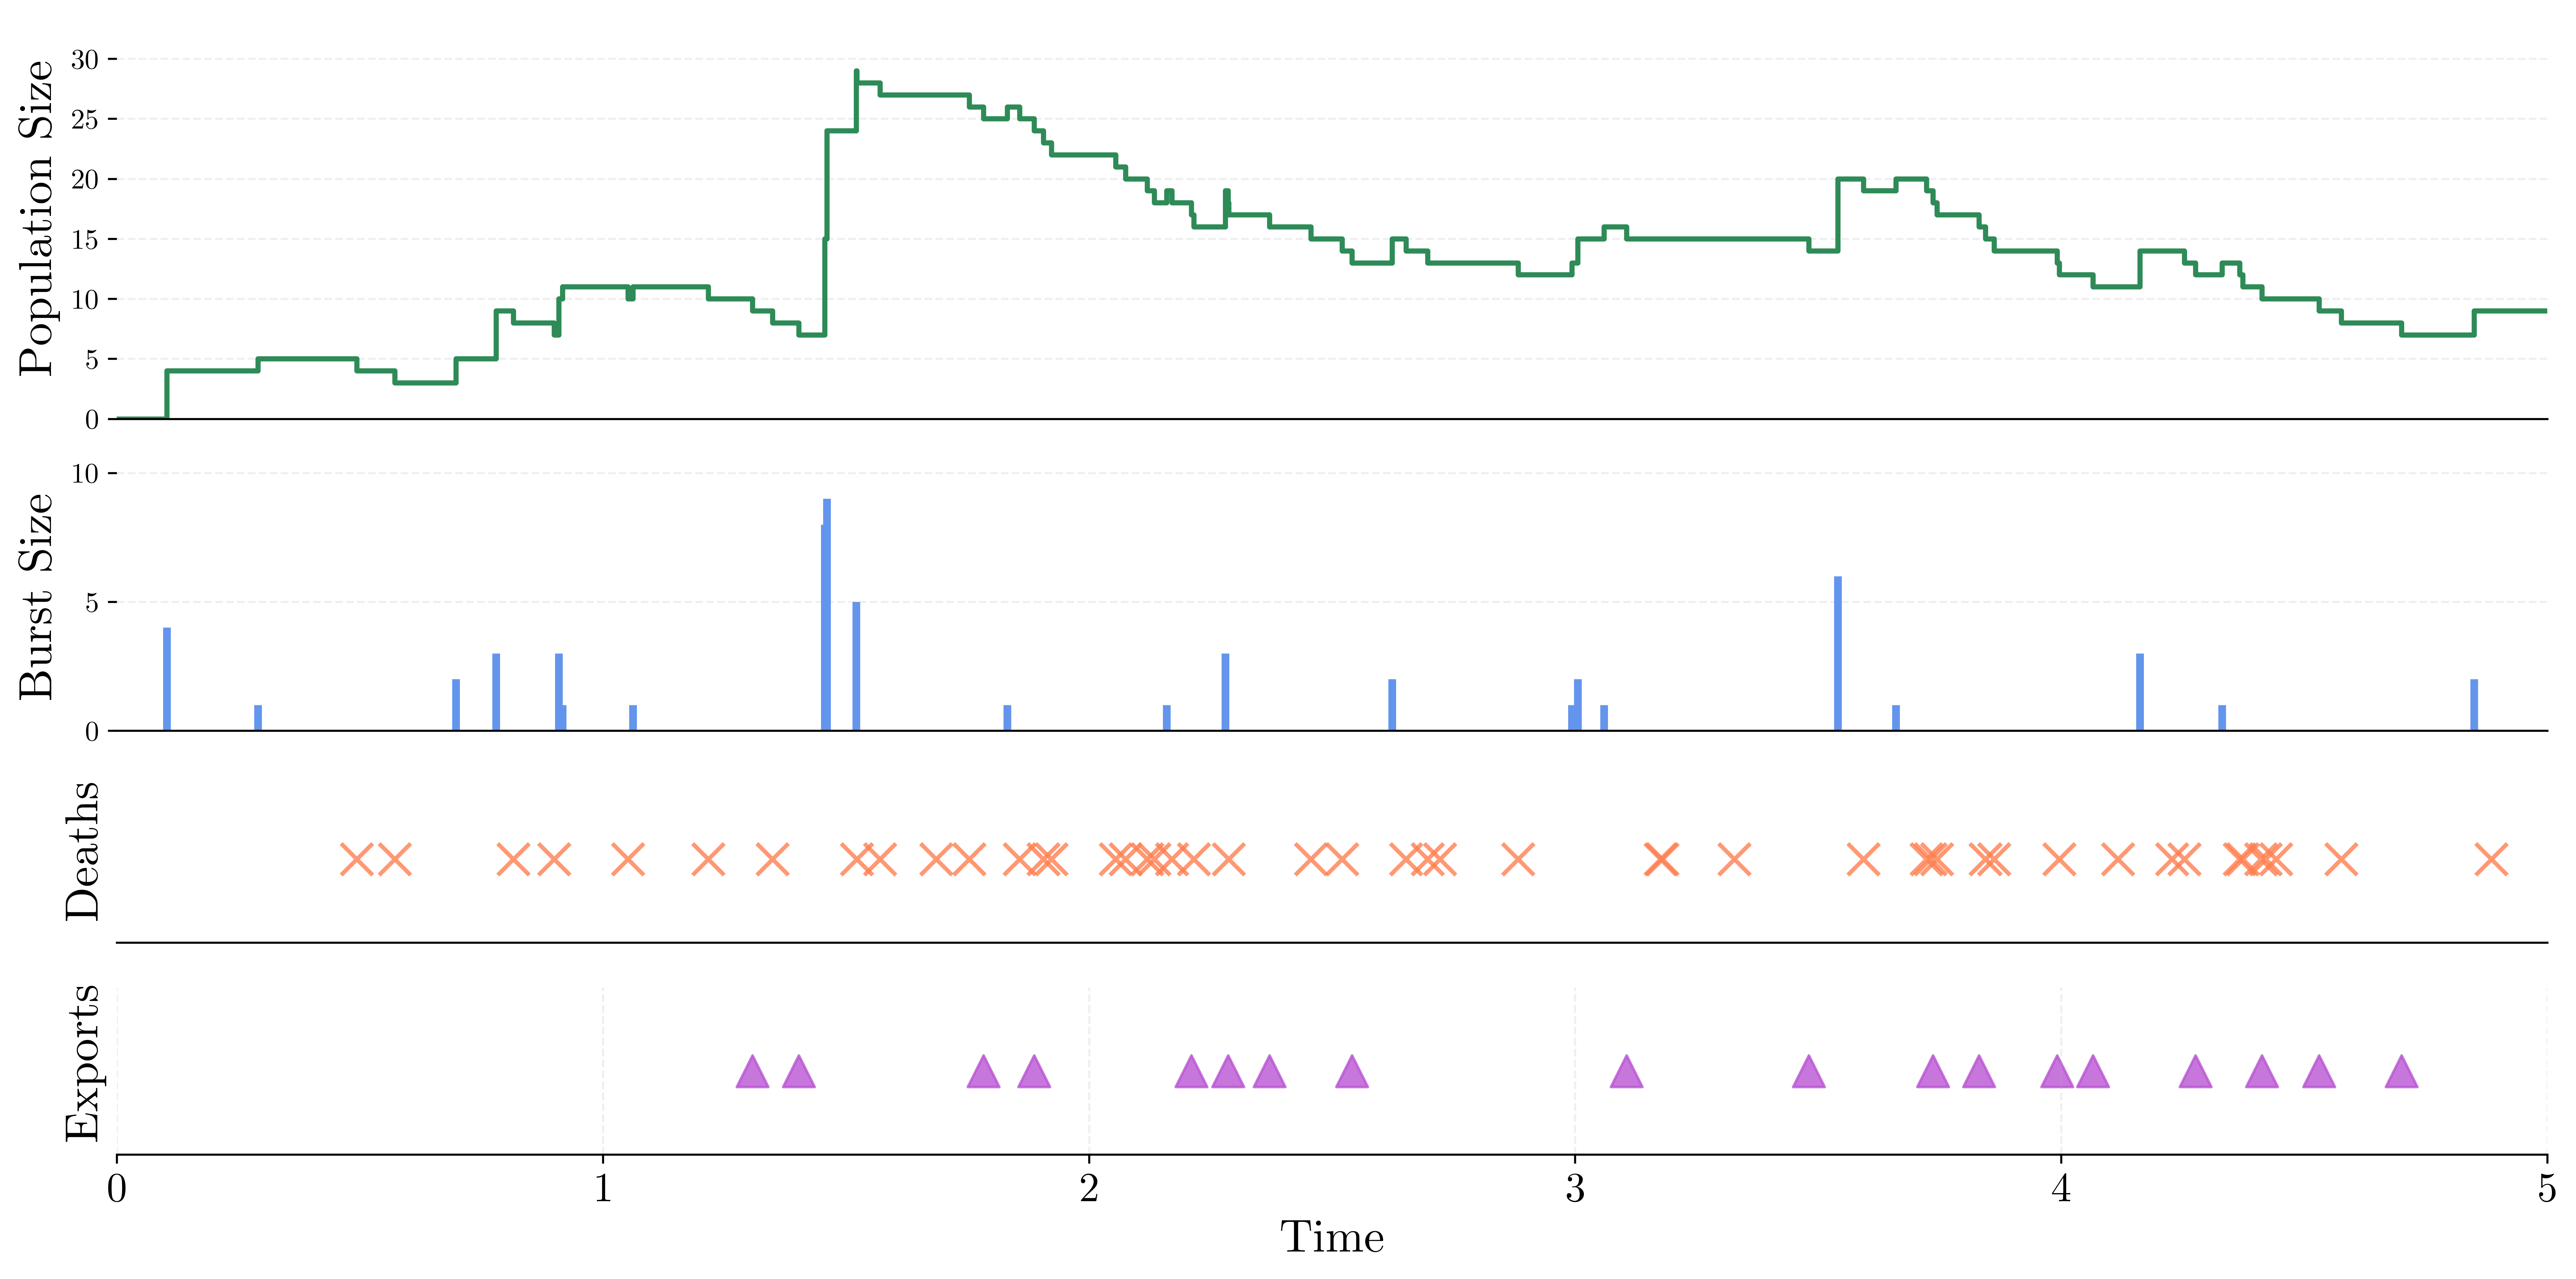

Time series plots saved!
Total birth events: 23
Total deaths: 47
Total exports: 18


In [65]:
"""
Create refined time series plots showing birth, death, and export events.
Uses thin vertical lines for a clean, minimalist look.
"""

birth_times, burst_sizes = sim.get_birth_times_and_sizes()
death_times = sim.get_death_events()
export_times = sim.get_export_events()
pop_times = np.unique(np.sort(np.concatenate((birth_times, death_times, export_times,[0,5]))))
pop = np.zeros(pop_times.shape)
for i, t in enumerate(pop_times):
    pop[i] = sim.count_alive_at_time(t)

np.random.seed(42)

#fig, axes = plt.subplots(3, 1, figsize=(14, 10))
#fig, axes = plt.subplots(4, 1, figsize=(14, 13))
fig, axes = plt.subplots(
    4, 1, figsize=(14, 7),
    gridspec_kw={'height_ratios': [0.6, 0.4, 0.25, 0.25]}
)
# --- plot 0: Population size over time ---
ax = axes[0]
ax.step(pop_times, pop, where='post', color=alive_color, linewidth=2)
ax.set_xlim(0, T)
ax.set_ylim(0, max(pop) * 1.15 if len(pop) > 0 else 1)
ax.set_ylabel(r'Population Size', fontsize=18, fontweight='bold')
#ax.set_title(r'Population Size Over Time', fontsize=20, fontweight='bold', pad=15)
ax.grid(alpha=0.2, linestyle='--')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot 1: Birth events with magnitudes ---
ax = axes[1]
if len(birth_times) > 0:
    for t, size in zip(birth_times, burst_sizes):
        ax.vlines(t, 0, size, colors=birth_event_ts_color, linewidth=3, alpha=1.0)
ax.set_xlim(0, T)
ax.set_ylim(0, max(burst_sizes) * 1.15 if len(burst_sizes) > 0 else 1)
ax.set_ylabel(r'Burst Size', fontsize=18, fontweight='bold')
#ax.set_title(r'Birth Events', fontsize=20, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# --- Plot 2: Death events ---
ax = axes[2]
if len(death_times) > 0:
    for t in death_times:
        #ax.vlines(t, 0, 1, colors='red', linewidth=2, alpha=0.7)
        ax.scatter(t, 0.5, marker='x', color=death_color, s=150, alpha=0.8)
ax.set_xlim(0, T)
ax.set_ylim(-0.1, 1.1)
ax.set_ylabel(r' Deaths', fontsize=18, fontweight='bold')
#ax.set_title(r'Death Events', fontsize=20, fontweight='bold', pad=15)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Plot 3: Export events ---
ax = axes[3]
if len(export_times) > 0:
    for t in export_times:
        #ax.vlines(t, 0, 1, colors='green', linewidth=2, alpha=0.7)
        ax.scatter(t, 0.5, color=export_color, marker='^', s=150, alpha=0.8)
ax.set_xlim(0, T)
ax.set_ylim(-0.1, 1.1)
ax.set_ylabel(r' Exports', fontsize=18, fontweight='bold')
#ax.set_title(r'Export Events', fontsize=20, fontweight='bold', pad=15)
ax.set_yticks([])
ax.tick_params(axis='both',labelsize=16)
ax.set_xlabel(r'Time', fontsize=18, fontweight='bold')
ax.grid(axis='x', alpha=0.2, linestyle='--')

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/cartoon_td_timeseries.svg', bbox_inches='tight', dpi=600)
plt.show()

print(f"Time series plots saved!")
print(f"Total birth events: {len(birth_times)}")
print(f"Total deaths: {len(death_times)}")
print(f"Total exports: {len(export_times)}")


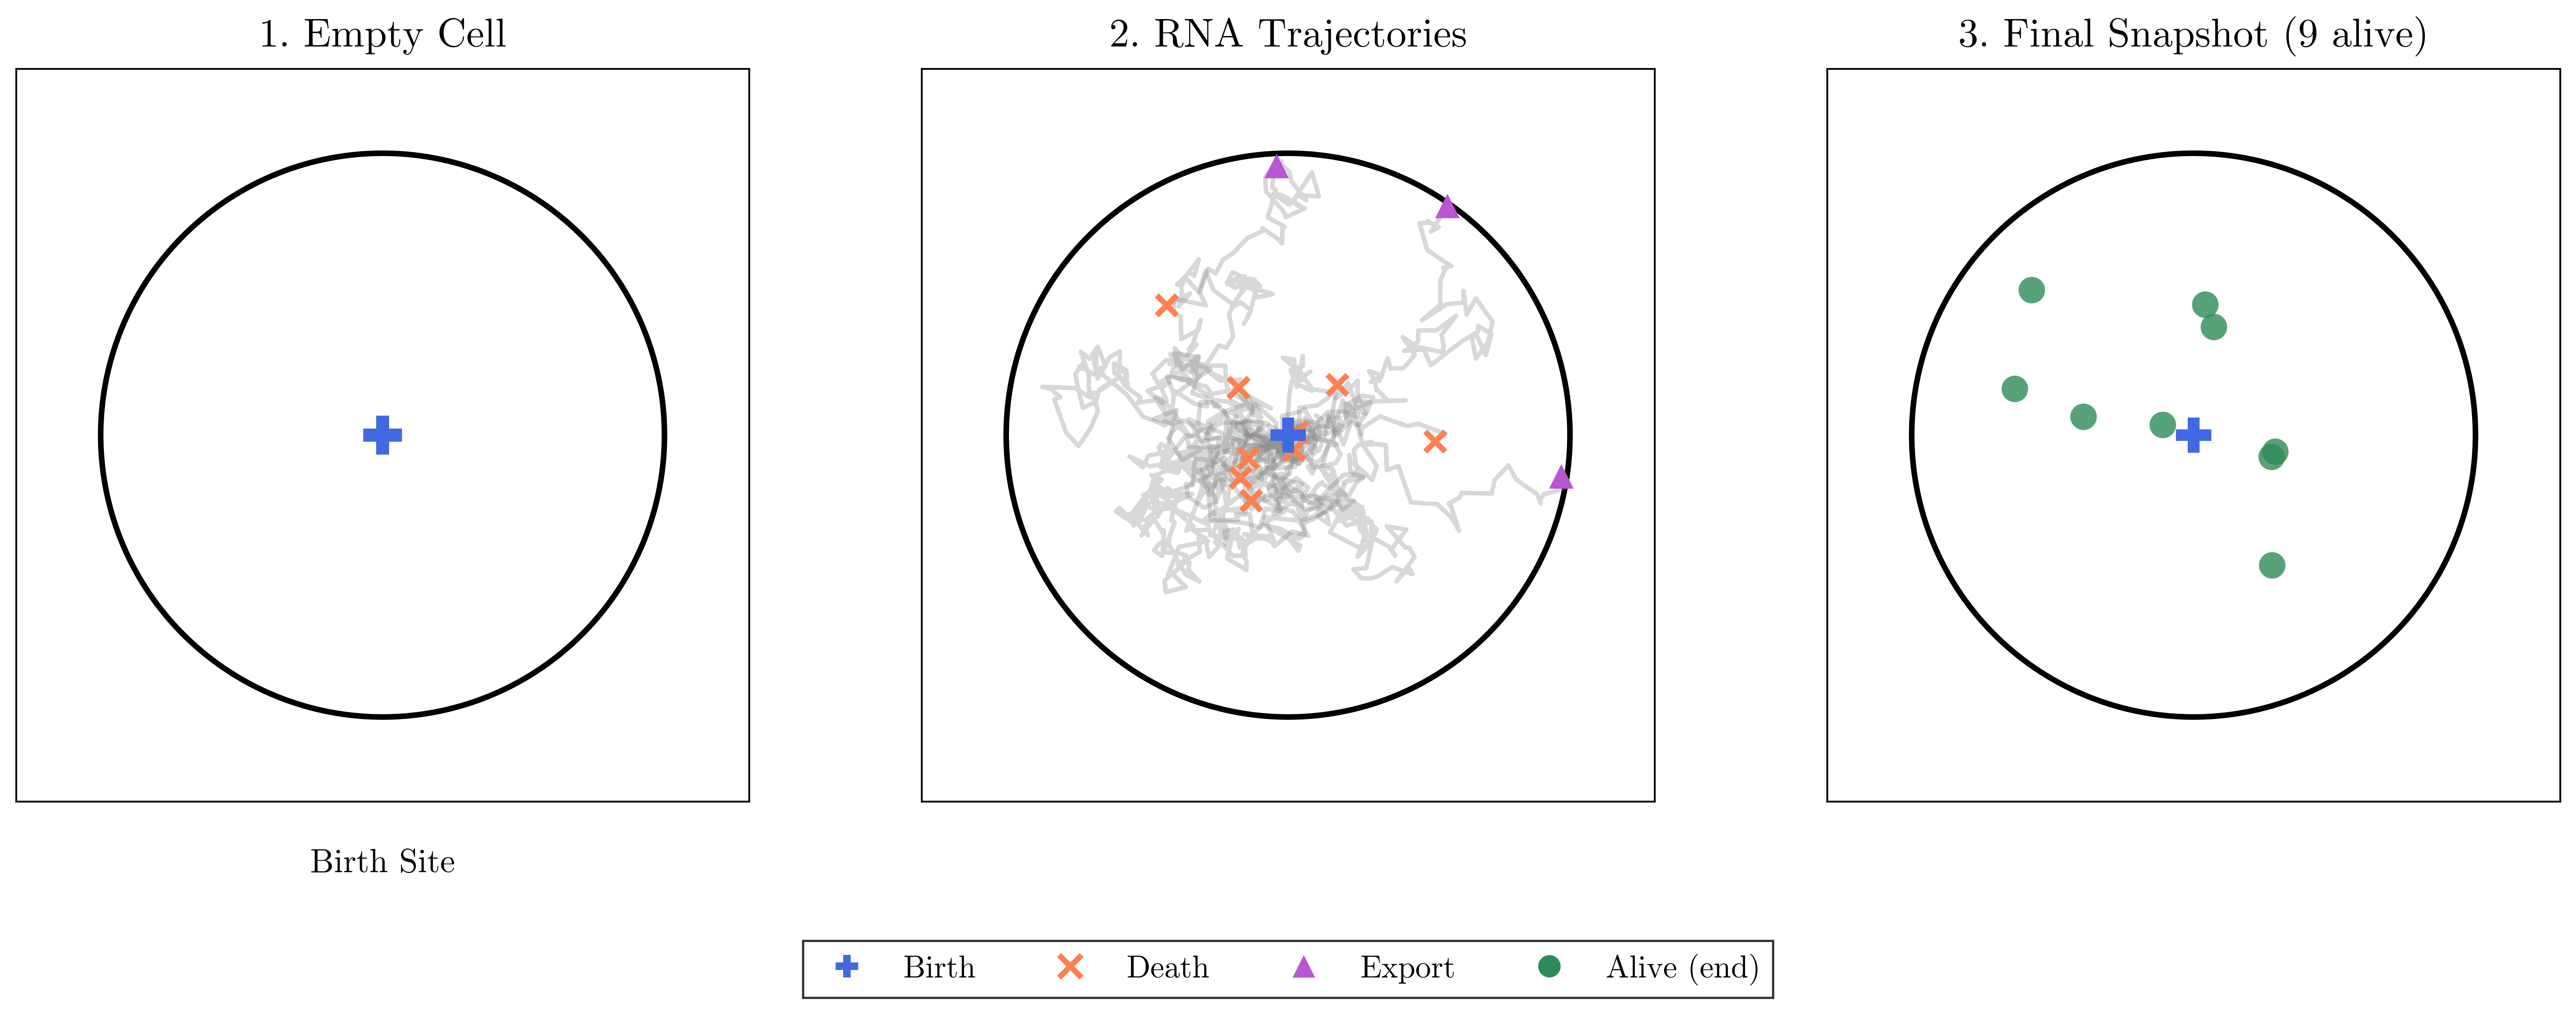

Snapshot plots saved!
Final alive particles: 9


In [30]:
"""
Create 2D cell snapshots showing:
1. Empty circular cell with birth site marked
2. Cell with RNA trajectories during simulation (2D brownian motion)
3. Final snapshot at end of simulation
Includes markers for birth, death, and export events.
"""

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Draw circular cell boundary
def draw_cell_circle(ax, radius=1.0):
    circle = plt.Circle((0, 0), radius, fill=False, color='black', linewidth=2.5)
    ax.add_patch(circle)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.grid(alpha=0.15, linestyle='--')


site_edge_color = 'none'
tss_marker = 'P'

# --- Snapshot 1: Empty cell with birth site marked ---
ax = axes[0]
draw_cell_circle(ax, sim.cell_radius)
ax.scatter([0], [0], s=300, marker=tss_marker, color=site_color, edgecolor=site_edge_color, linewidth=1, zorder=5, label='Birth Site')
ax.text(0, -1.55, 'Birth Site', ha='center', fontsize=15, fontweight='bold')
ax.set_title('1. Empty Cell', fontsize=18, fontweight='bold', pad=10)
ax.set_xticks([]) 
ax.set_yticks([])

# --- Snapshot 2: Intermediate - show some trajectories ---
ax = axes[1]
draw_cell_circle(ax, sim.cell_radius)
n_particles_to_show = min(12, len(sim.particles))
for i, particle in enumerate(sim.particles[:n_particles_to_show]):
    if len(particle.trajectory) > 1:
        times = np.array([t for t, x, y in particle.trajectory])
        xs = np.array([x for t, x, y in particle.trajectory])
        ys = np.array([y for t, x, y in particle.trajectory])
        ax.plot(xs, ys, color=trajectory_color, alpha=0.3, linewidth=2)
        
        # Mark start (birth)
        ax.scatter([xs[0]], [ys[0]], s=60, color=site_color, marker=tss_marker, zorder=4)
        
        # Mark end or exit
        if particle.export_time is not None:
            # Particle was exported
            ax.scatter([xs[-1]], [ys[-1]], s=120, marker='^', color=export_color, 
                      edgecolor='none', linewidth=1.5, zorder=4)
        elif particle.death_time is not None:
            # Particle died (degraded)
            ax.scatter([xs[-1]], [ys[-1]], s=80, marker='x', color=death_color, linewidth=2.5, zorder=4)

ax.scatter([0], [0], s=250, marker=tss_marker, color=site_color, edgecolor=site_edge_color, linewidth=1, zorder=5)
ax.set_title('2. RNA Trajectories', fontsize=18, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])

# --- Snapshot 3: Final positions of RNA that survived ---
ax = axes[2]
draw_cell_circle(ax, sim.cell_radius)

# Collect final positions of particles still in cell
final_xs = []
final_ys = []
for particle in sim.particles:
    if particle.death_time is None and particle.export_time is None:
        final_x = particle.trajectory[-1][1]
        final_y = particle.trajectory[-1][2]
        final_xs.append(final_x)
        final_ys.append(final_y)

if final_xs:
    ax.scatter(final_xs, final_ys, s=140, marker='o', color=alive_color, edgecolor='none', linewidth=1.5, alpha=0.8, zorder=4)

ax.scatter([0], [0], s=250, marker=tss_marker, color=site_color, edgecolor=site_edge_color, linewidth=1, zorder=5)
title_text = f'3. Final Snapshot ({len(final_xs)} alive)'
ax.set_title(title_text, fontsize=18, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])

# --- Add legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=tss_marker, color=site_color, markerfacecolor=site_color, markeredgecolor=site_edge_color, linestyle = 'none',
           markersize=10, markeredgewidth=0.75, label='Birth'),
    Line2D([0], [0], marker='x', color=death_color, markerfacecolor=death_color, markersize=10, linestyle = 'none',
           markeredgewidth=2.5, label='Death'),
    Line2D([0], [0], marker='^', color=export_color, markerfacecolor=export_color, markeredgecolor='none', linestyle = 'none',
           markersize=10, markeredgewidth=1.5, label='Export'),
    Line2D([0], [0], marker='o', color=alive_color, markerfacecolor=alive_color, markeredgecolor='none', linestyle = 'none',
           markersize=10, markeredgewidth=1.5, label='Alive (end)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
          ncol=4, fontsize=14, frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('results/cartoon_td_snapshots.svg', bbox_inches='tight', dpi=600)
plt.show()

print(f"Snapshot plots saved!")
print(f"Final alive particles: {len(final_xs)}")


In [31]:
# Parameters
cell_radius = np.sqrt(2)
sim_double = SpatialStochasticSimulator(kplus=kplus, kminus=kminus, rburst=rburst, 
                                 D=D, cell_radius=cell_radius)
sim_double.simulate(T=T, dt=0.01, seed=42)

In [32]:
# Parameters
cell_radius = np.sqrt(1/2)
sim_half = SpatialStochasticSimulator(kplus=kplus, kminus=kminus, rburst=rburst, 
                                 D=D, cell_radius=cell_radius)
sim_half.simulate(T=T, dt=0.01, seed=42)

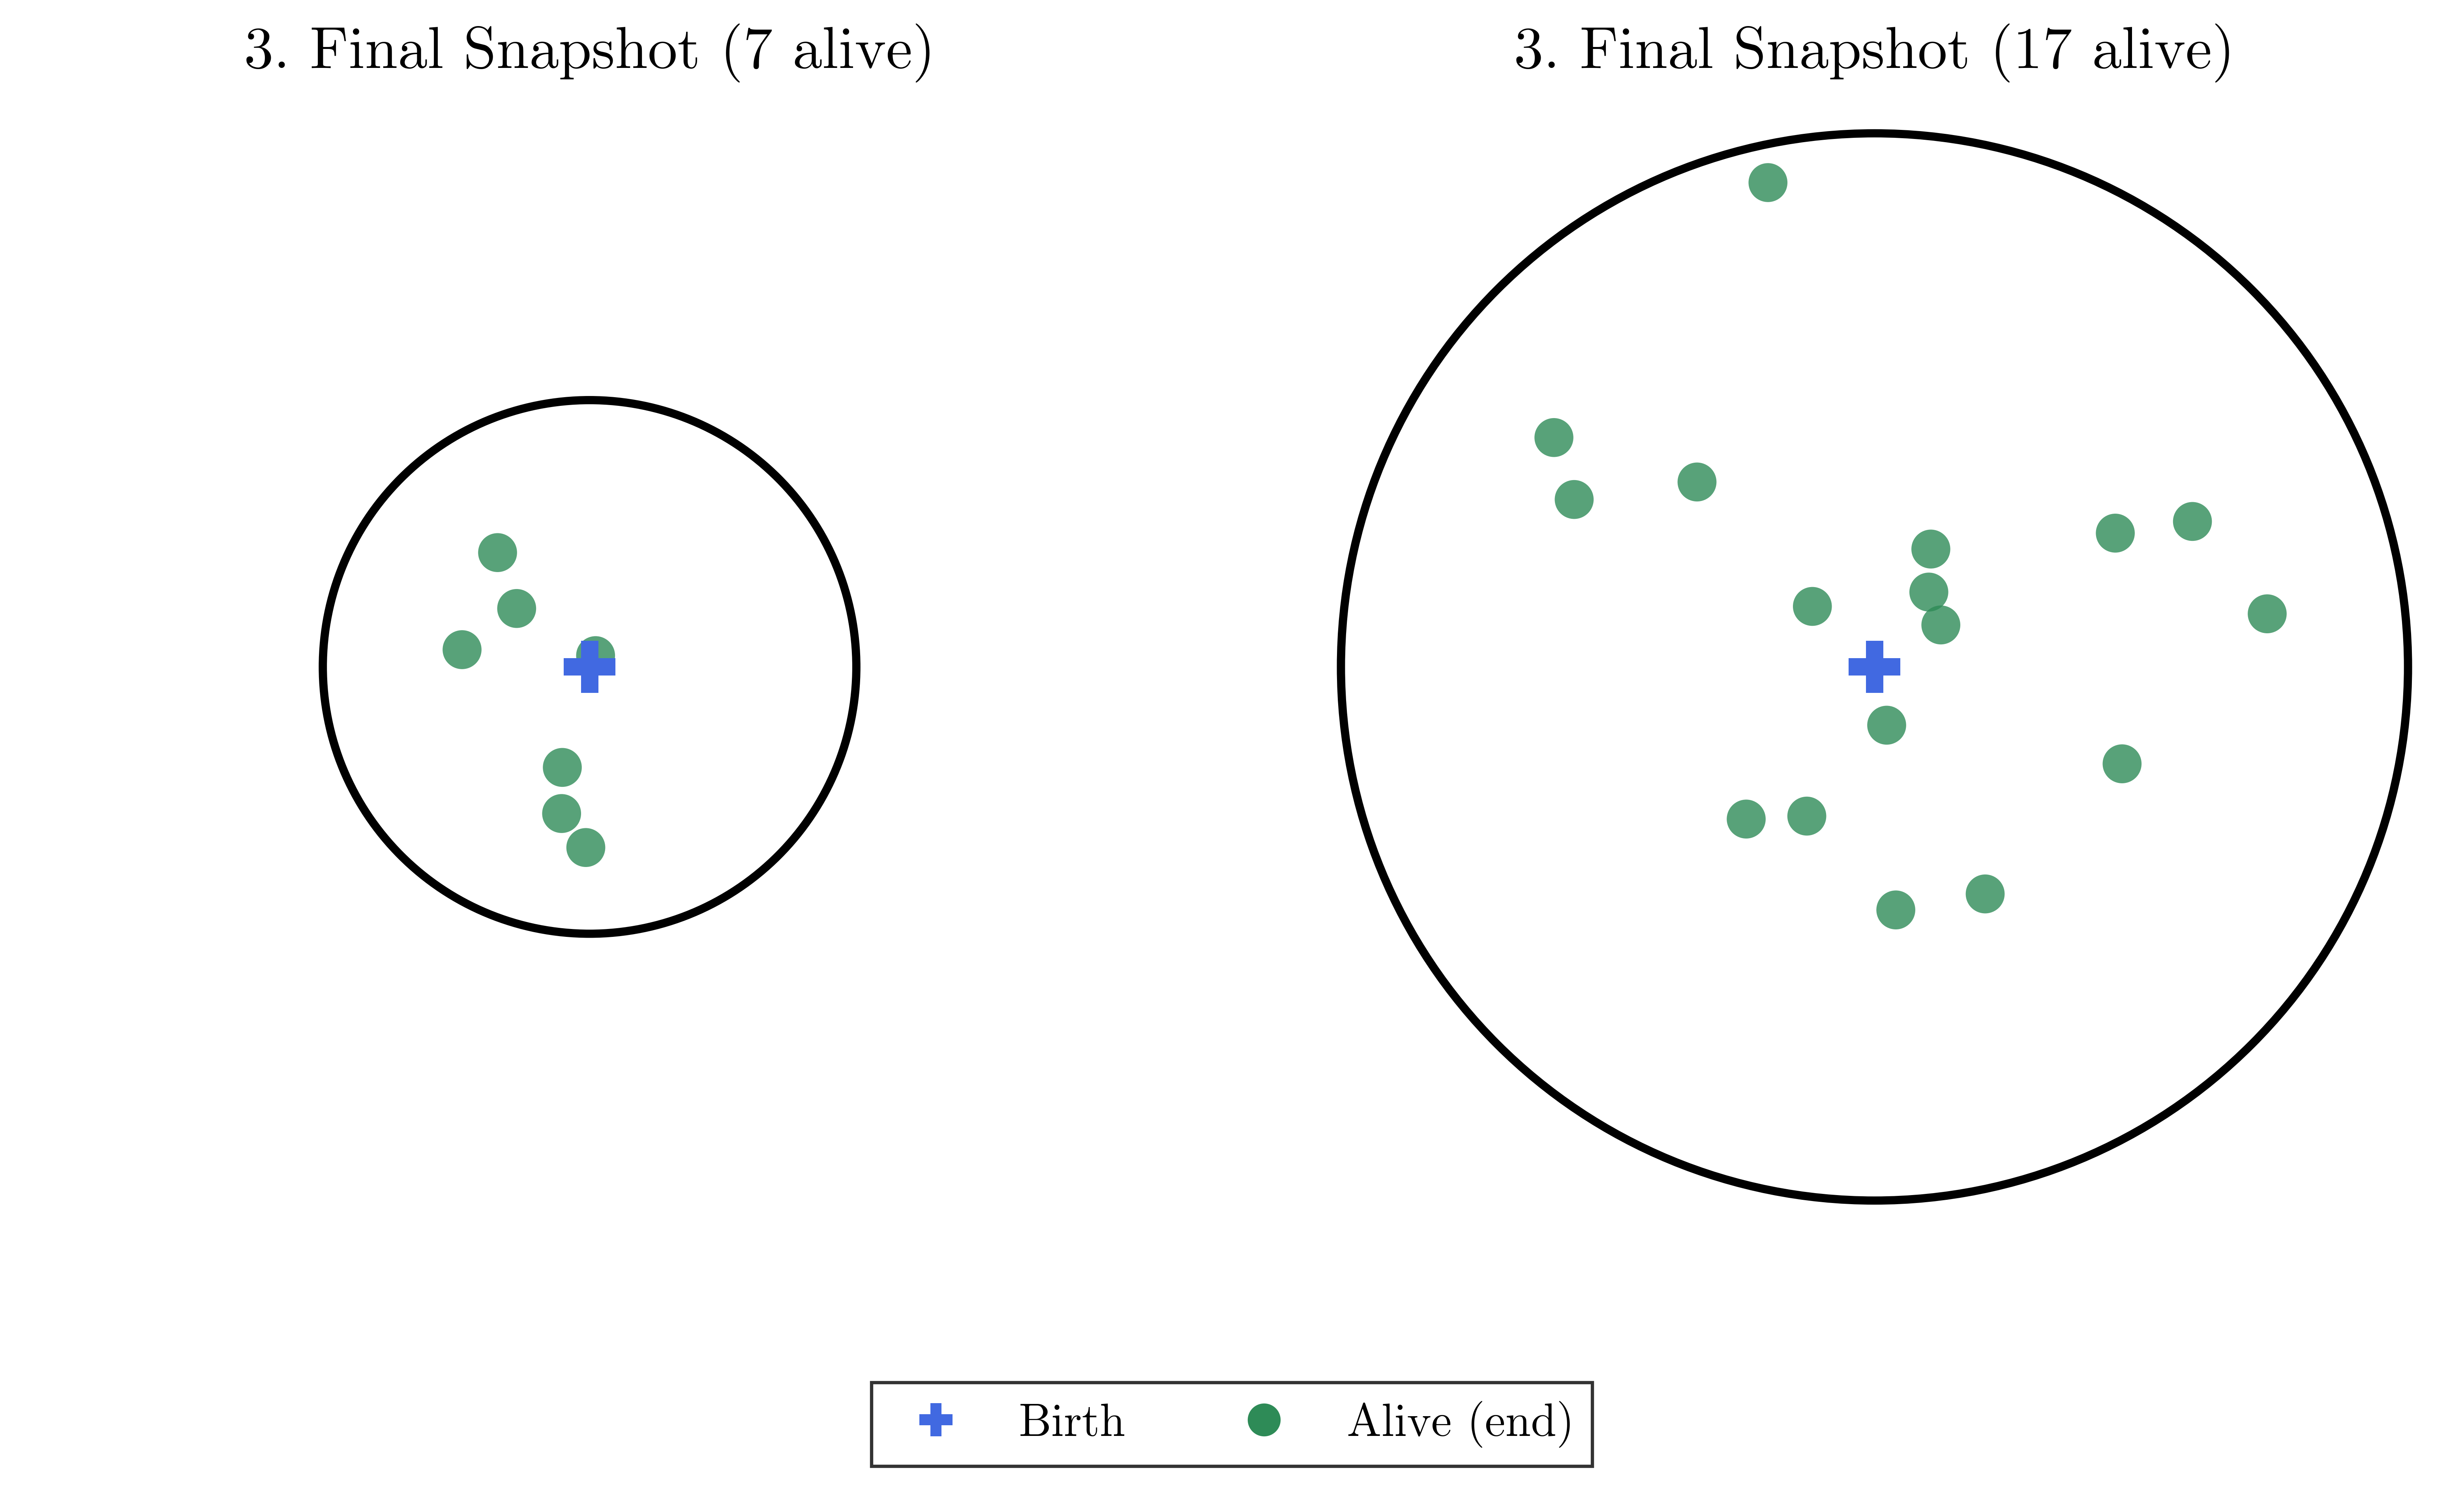

Snapshot plots saved!
Final alive particles: 17


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# Draw circular cell boundary
def draw_cell_circle(ax, radius=1.0):
    circle = plt.Circle((0, 0), radius, fill=False, color='black', linewidth=2.5)
    ax.add_patch(circle)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.grid(alpha=0.15, linestyle='--')
    for spine in ax.spines.values():
        spine.set_visible(False)


site_edge_color = 'gray'

# --- Snapshot 1: Half area
ax = axes[0]
draw_cell_circle(ax, sim_half.cell_radius)

# Collect final positions of particles still in cell
final_xs = []
final_ys = []
for particle in sim_half.particles:
    if particle.death_time is None and particle.export_time is None:
        final_x = particle.trajectory[-1][1]
        final_y = particle.trajectory[-1][2]
        final_xs.append(final_x)
        final_ys.append(final_y)

if final_xs:
    ax.scatter(final_xs, final_ys, s=140, marker='o', color=alive_color, edgecolor='none', linewidth=1.5, alpha=0.8, zorder=4)

ax.scatter([0], [0], s=250, marker=tss_marker, color=site_color, edgecolor='none', linewidth=1, zorder=5)
title_text = f'3. Final Snapshot ({len(final_xs)} alive)'
ax.set_title(title_text, fontsize=18, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])


# --- Snapshot 2: Double area ---
ax = axes[1]
draw_cell_circle(ax, sim_double.cell_radius)

# Collect final positions of particles still in cell
final_xs = []
final_ys = []
for particle in sim_double.particles:
    if particle.death_time is None and particle.export_time is None:
        final_x = particle.trajectory[-1][1]
        final_y = particle.trajectory[-1][2]
        final_xs.append(final_x)
        final_ys.append(final_y)

if final_xs:
    ax.scatter(final_xs, final_ys, s=140, marker='o', color=alive_color, edgecolor='none', linewidth=1.5, alpha=0.8, zorder=4)

ax.scatter([0], [0], s=250, marker=tss_marker, color=site_color, edgecolor='none', linewidth=1, zorder=5)
title_text = f'3. Final Snapshot ({len(final_xs)} alive)'
ax.set_title(title_text, fontsize=18, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])



# --- Add legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=tss_marker, color='w', markerfacecolor=site_color, markeredgecolor='none', 
           markersize=10, markeredgewidth=0.75, label='Birth'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=alive_color, markeredgecolor='none', 
           markersize=10, markeredgewidth=1.5, label='Alive (end)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
          ncol=4, fontsize=14, frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('results/cartoon_td_snapshots_perturbed.svg', bbox_inches='tight', dpi=600)
plt.show()

print(f"Snapshot plots saved!")
print(f"Final alive particles: {len(final_xs)}")


In [34]:

"""
Modified simulator for elliptical cells with configurable birth site.
"""

class EllipticalStochasticSimulator(SpatialStochasticSimulator):
    """
    Simulates a 2D spatial stochastic model in an elliptical cell.
    
    Parameters same as parent, but with semi_axes (a, b) instead of cell_radius.
    """
    
    def __init__(self, 
                 kplus: float,
                 kminus: float,
                 rburst: float,
                 D: float,
                 semi_axes: Tuple[float, float] = (1.0, 0.6),  # (a, b) semi-major/minor axes
                 birth_site: Tuple[float, float] = None):
        
        self.kplus = kplus
        self.kminus = kminus
        self.rburst = rburst
        self.D = D
        self.semi_axes = semi_axes  # (a, b)
        self.birth_site = birth_site if birth_site is not None else (0.0, 0.0)
        self.cell_radius = 1.0  # dummy for compatibility
        
        self.birth_events = []
        self.particles: ListType[Particle] = []
    
    def _is_inside_ellipse(self, x: float, y: float) -> bool:
        """Check if point (x, y) is inside the ellipse"""
        a, b = self.semi_axes
        return (x / a) ** 2 + (y / b) ** 2 <= 1.0
    
    def _diffuse_particle(self, particle: Particle, T: float, dt: float):
        """Diffuse a particle in 2D elliptical cell"""
        time = particle.trajectory[-1][0]
        x = particle.trajectory[-1][1]
        y = particle.trajectory[-1][2]
        
        sqrt_2Ddt = np.sqrt(2.0 * self.D * dt)
        
        while time < T:
            if particle.death_time is not None and time >= particle.death_time:
                break
            
            # Take 2D diffusion step
            time += dt
            x += np.random.normal(0, sqrt_2Ddt)
            y += np.random.normal(0, sqrt_2Ddt)
            
            # Check ellipse boundary
            if not self._is_inside_ellipse(x, y):
                particle.export_time = time
                break
            
            if time > T:
                time = T
            
            particle.trajectory.append((time, x, y))


In [35]:

# Create elliptical simulations

# Ellipse 1: Standard ellipse (centered birth)
semi_axes_ellipse = (1.2, 0.7)
sim_ellipse = EllipticalStochasticSimulator(
    kplus=kplus, kminus=kminus, rburst=rburst, D=D,
    semi_axes=semi_axes_ellipse,
    birth_site=(0.0, 0.0)
)
sim_ellipse.simulate(T=T, dt=0.01, seed=42)

# Ellipse 2: Ellipse with non-centered birth site
birth_site_offset = (0.5, -0.3)
sim_ellipse_offset = EllipticalStochasticSimulator(
    kplus=kplus, kminus=kminus, rburst=rburst, D=D,
    semi_axes=semi_axes_ellipse,
    birth_site=birth_site_offset
)
sim_ellipse_offset.simulate(T=T, dt=0.01, seed=42)

print("Elliptical simulations complete!")
print(f"Sim 1 - Center birth: {sim_ellipse.birth_site}, Alive: {sum(1 for p in sim_ellipse.particles if p.death_time is None and p.export_time is None)}")
print(f"Sim 2 - Offset birth: {sim_ellipse_offset.birth_site}, Alive: {sum(1 for p in sim_ellipse_offset.particles if p.death_time is None and p.export_time is None)}")


Elliptical simulations complete!
Sim 1 - Center birth: (0.0, 0.0), Alive: 12
Sim 2 - Offset birth: (0.5, -0.3), Alive: 4


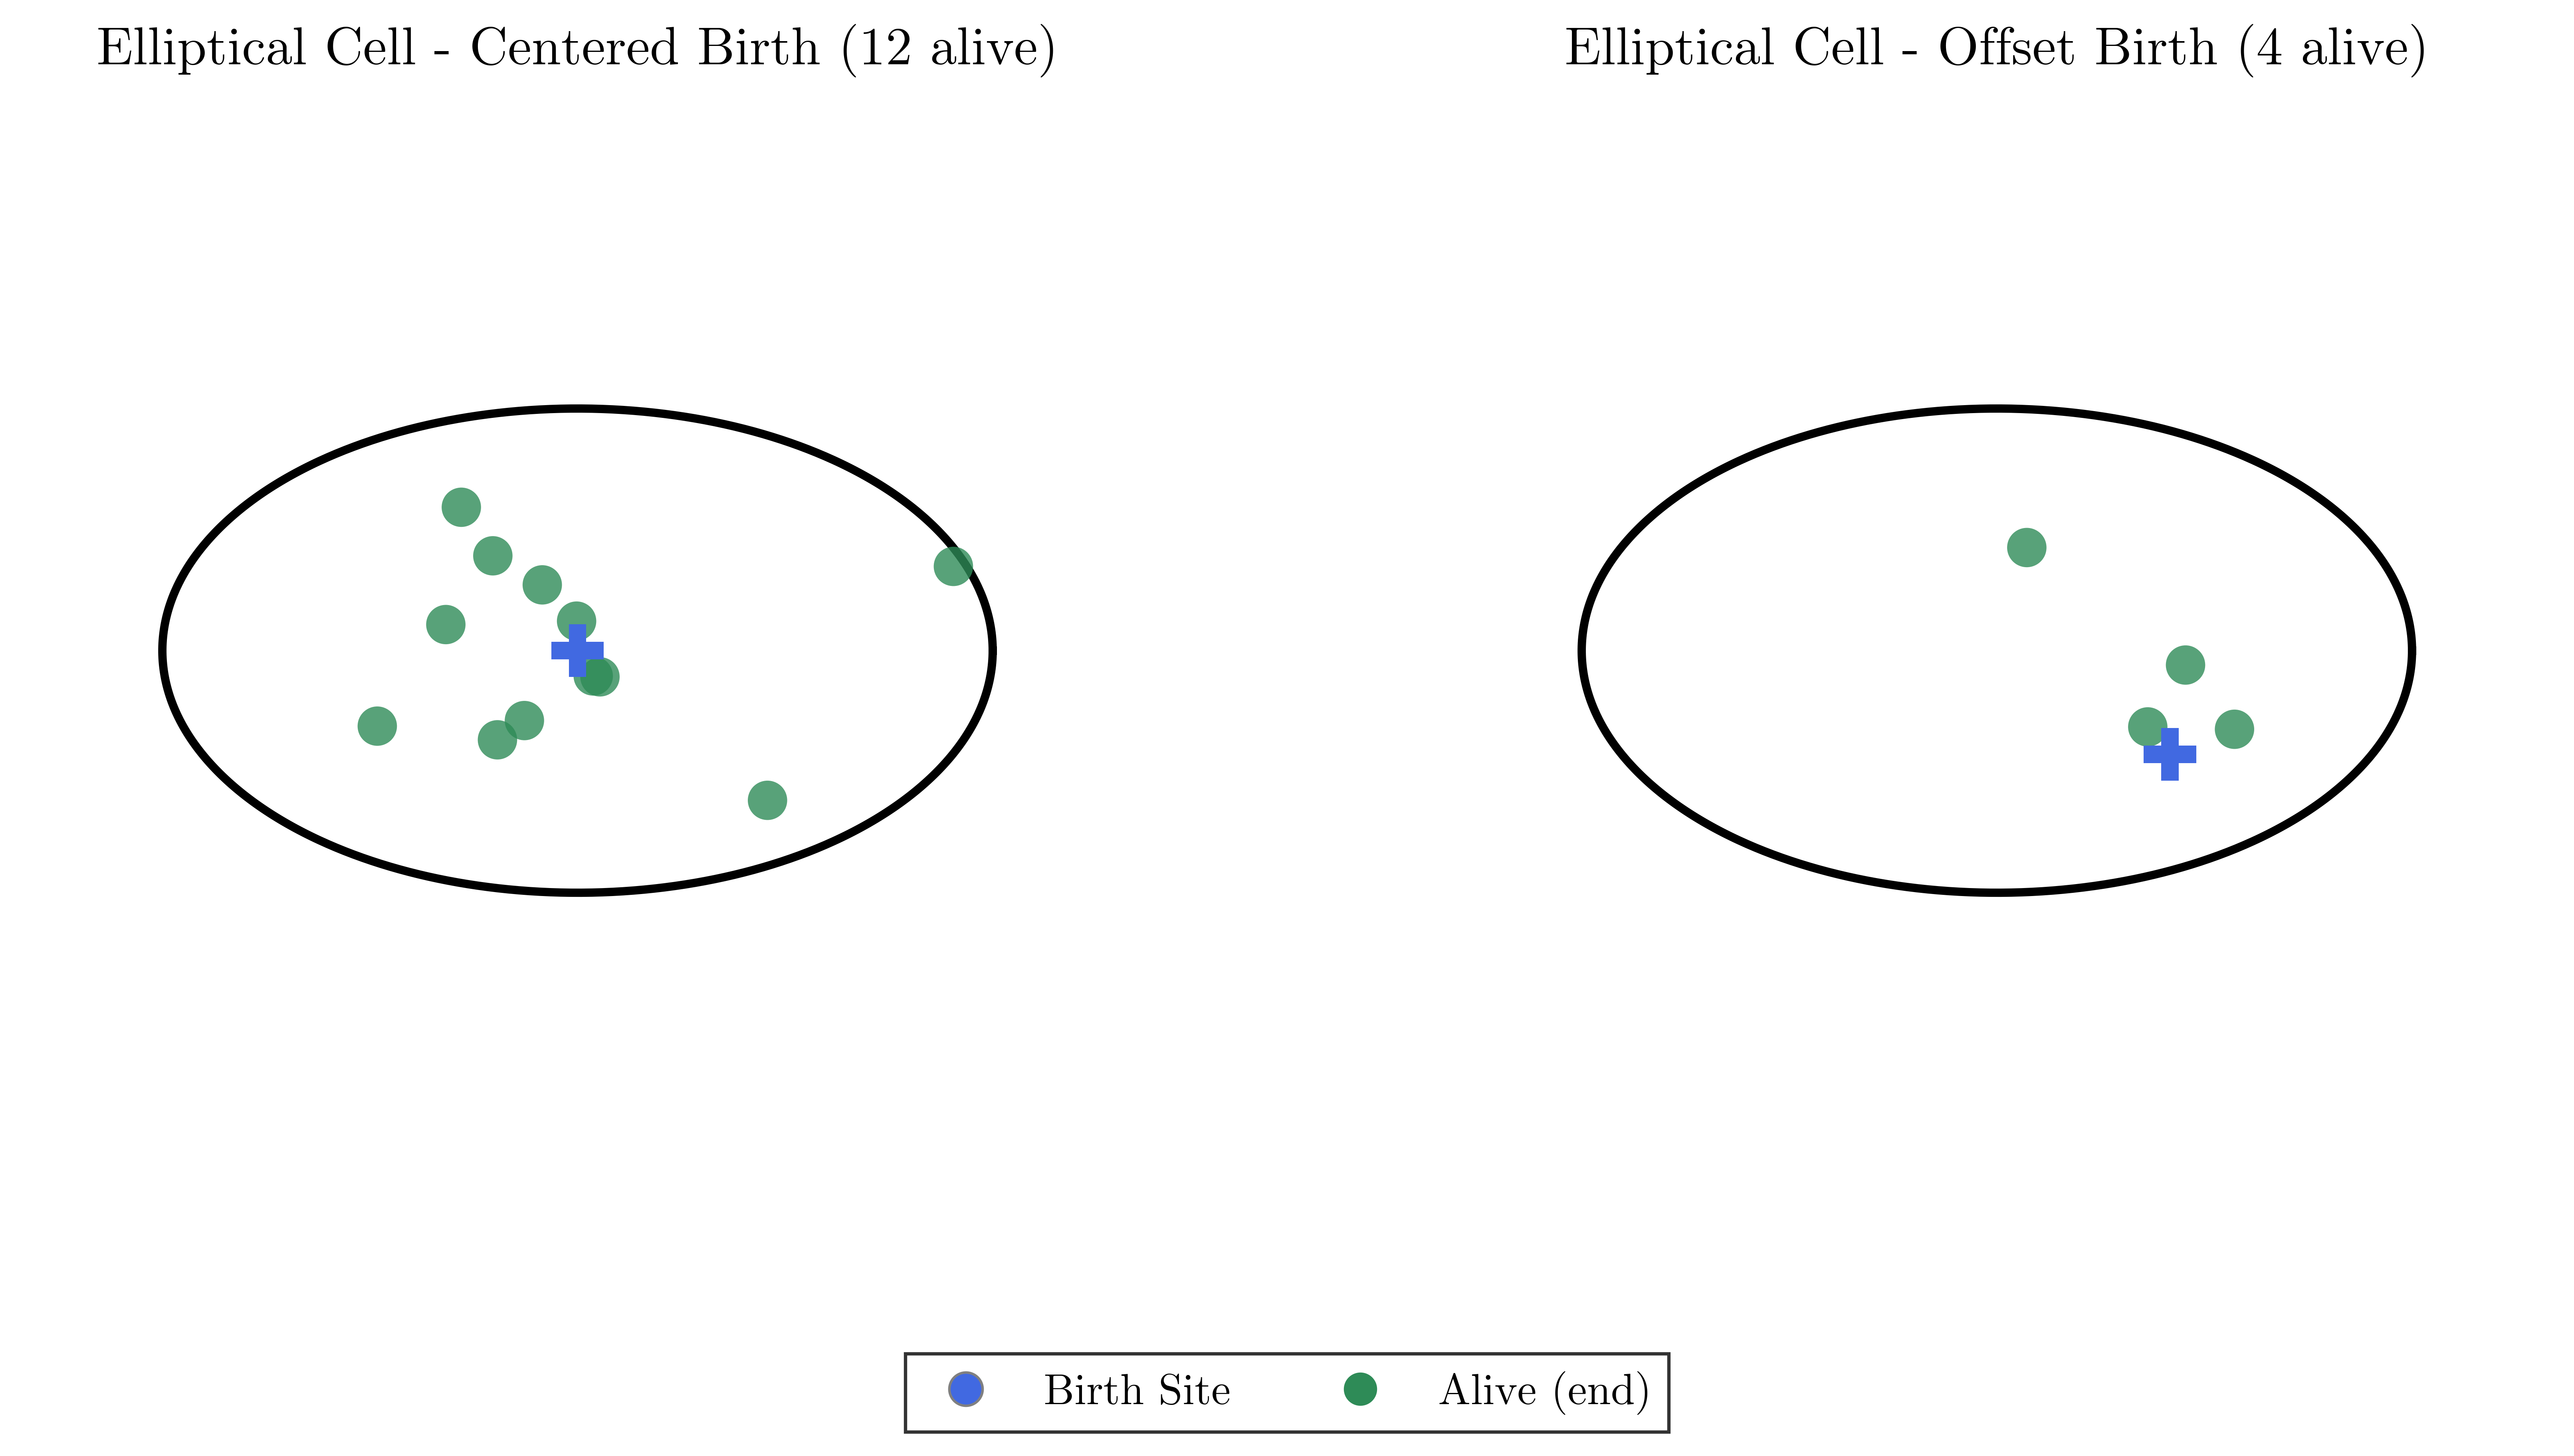

Elliptical snapshots saved!


In [40]:

# Plot elliptical simulations side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

def draw_ellipse(ax, semi_axes, xlim=(-1.6, 1.6), ylim=(-1.6, 1.6)):
    """Draw ellipse on axes"""
    a, b = semi_axes
    theta = np.linspace(0, 2*np.pi, 500)
    x_ellipse = a * np.cos(theta)
    y_ellipse = b * np.sin(theta)
    ax.plot(x_ellipse, y_ellipse, color='black', linewidth=2.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.15, linestyle='--')
    for spine in ax.spines.values():
        spine.set_visible(False)

# --- Plot 1: Centered birth site ---
ax = axes[0]
draw_ellipse(ax, semi_axes_ellipse)

final_xs = []
final_ys = []
for particle in sim_ellipse.particles:
    if particle.death_time is None and particle.export_time is None:
        final_x = particle.trajectory[-1][1]
        final_y = particle.trajectory[-1][2]
        final_xs.append(final_x)
        final_ys.append(final_y)

if final_xs:
    ax.scatter(final_xs, final_ys, s=140, marker='o', color=alive_color, 
              edgecolor='none', linewidth=1.5, alpha=0.8, zorder=4)

ax.scatter([0], [0], s=250, marker=tss_marker, color=site_color, 
          edgecolor='none', linewidth=1, zorder=5)
title_text = f'Elliptical Cell - Centered Birth ({len(final_xs)} alive)'
ax.set_title(title_text, fontsize=16, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])

# --- Plot 2: Offset birth site ---
ax = axes[1]
draw_ellipse(ax, semi_axes_ellipse)

final_xs = []
final_ys = []
for particle in sim_ellipse_offset.particles:
    if particle.death_time is None and particle.export_time is None:
        final_x = particle.trajectory[-1][1]
        final_y = particle.trajectory[-1][2]
        final_xs.append(final_x)
        final_ys.append(final_y)

if final_xs:
    ax.scatter(final_xs, final_ys, s=140, marker='o', color=alive_color, 
              edgecolor='none', linewidth=1.5, alpha=0.8, zorder=4)

ax.scatter([birth_site_offset[0]], [birth_site_offset[1]], s=250, marker=tss_marker, 
          color=site_color, edgecolor='none', linewidth=1, zorder=5)
title_text = f'Elliptical Cell - Offset Birth ({len(final_xs)} alive)'
ax.set_title(title_text, fontsize=16, fontweight='bold', pad=10)
ax.set_xticks([])
ax.set_yticks([])

# --- Add legend ---
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=site_color, 
           markeredgecolor=site_edge_color, markersize=10, markeredgewidth=0.75, label='Birth Site'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=alive_color, 
           markeredgecolor='none', markersize=10, markeredgewidth=1.5, label='Alive (end)'),
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), 
          ncol=2, fontsize=13, frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('results/cartoon_td_snapshots_elliptical.svg', bbox_inches='tight', dpi=600)
plt.show()

print(f"Elliptical snapshots saved!")


### Lotka Volterra 

In [20]:
import lotka_volterra as lv
import numpy as np
from matplotlib import pyplot as plt

from matplotlib.lines import Line2D

In [21]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['CMU Serif'],
    'mathtext.fontset': 'stix',
    'mathtext.rm': 'CMU Serif',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.title_fontsize': 10,
    'figure.dpi': 600,
    'savefig.dpi': 600,
    'lines.linewidth': 1.6,
    'lines.markersize': 8,
    'errorbar.capsize': 2.5,
    'svg.fonttype' : 'none',
    'svg.hashsalt' : '42'
})

TeX  NOT subset; don't know how to subset; dropped


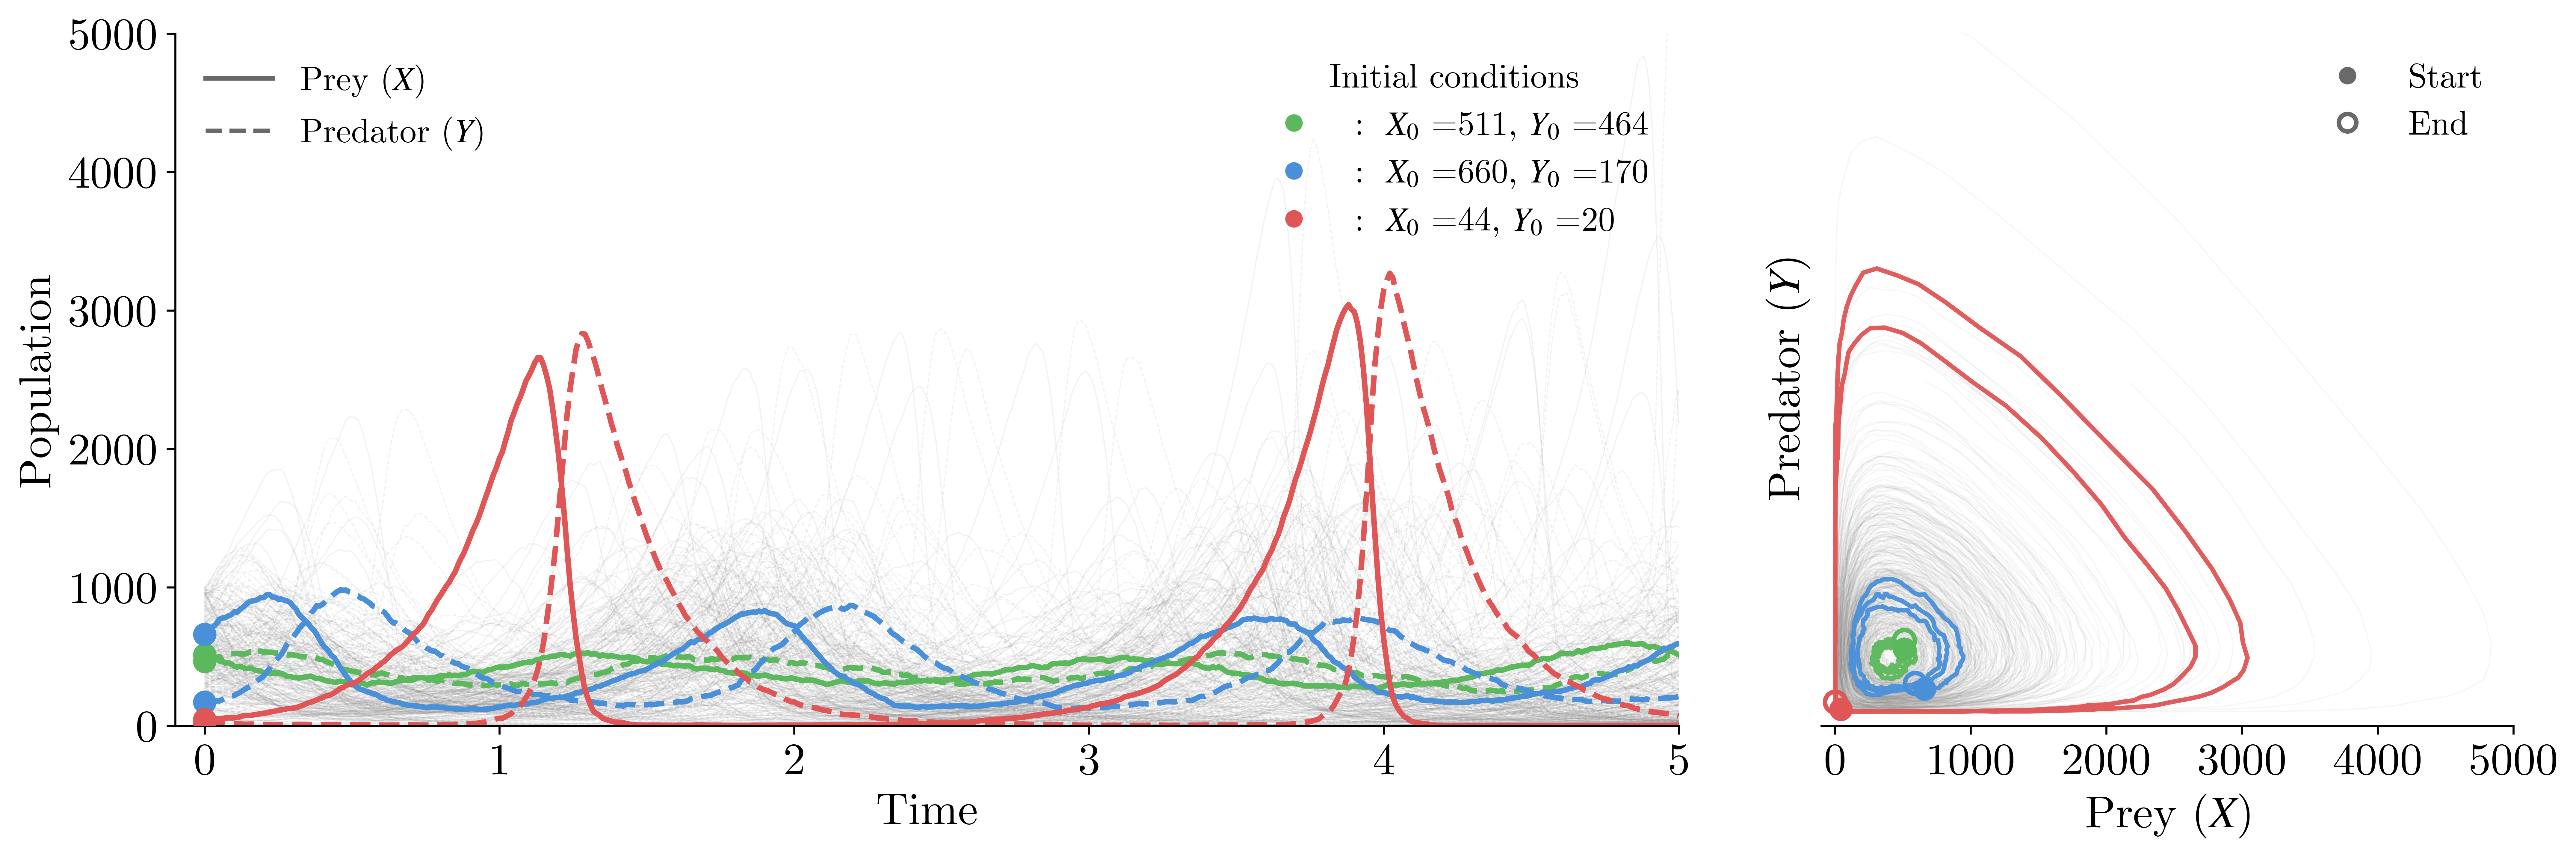

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

## Parameters
sample_size = 128
alpha, beta, gamma, delta = 4, 0.01, 4, 1
t_max = 5
dt = 0.01

fs = 1.5


np.random.seed(9)
ic = np.random.choice(1000, (sample_size, 2)) + 1
times, ts = lv.tau_leaping(ic, t_max, alpha, beta, gamma, delta, dt=dt, seed=9)

# ── Regime indices ────────────────────────────────────────────────────────────
idx_flat   = 74
idx_normal = 52
idx_wide   = 102

regime_indices = [idx_flat, idx_normal, idx_wide]
regime_names   = ['', '', '']
# Brighter versions of sage/slate/dusty-rose
regime_colors  = ["#5cb85c", '#4a90d9', '#e05555'] #'#5cb85c'

prey_color ='gray' # 'teal'
pred_color ='gray' # 'coral'
bg_alpha   = 0.10

# ── Layout: single row — [time series | phase portrait] ───────────────────────
fig = plt.figure(figsize=(17, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2,1], wspace=0.1)

#fig, (ax_t, ax_p) = plt.subplots(1, 2, figsize=(13, 2), gridspec_kw={'wspace': 0.08})

ax_t = fig.add_subplot(gs[0])   # time series
ax_p = fig.add_subplot(gs[1])   # phase portrait

# ══════════════════════════════════════════════════════════════════════════════
# TIME SERIES
# ══════════════════════════════════════════════════════════════════════════════

# Background spaghetti
ax_t.plot(times, ts[:, :, 0].T, color=prey_color, alpha=bg_alpha, lw=0.5, linestyle='-')
ax_t.plot(times, ts[:, :, 1].T, color=pred_color, alpha=bg_alpha, lw=0.5, linestyle='--')

# Characteristic traces
for idx, color, name in zip(regime_indices, regime_colors, regime_names):
    ax_t.plot(times, ts[idx, :, 0], color=color, alpha=1.0, lw=2.2, linestyle='-',  label=name)
    ax_t.plot(times, ts[idx, :, 1], color=color, alpha=1.0, lw=2.2, linestyle='--')

    # IC dot at t=0
    ax_t.scatter(times[0], ts[idx, 0, 0], color=color, s=70, zorder=6, marker='o')
    ax_t.scatter(times[0], ts[idx, 0, 1], color=color, s=70, zorder=6, marker='o')

ax_t.set_xlim(-0.1, 5)
ax_t.set_ylim(0, 5000)
ax_t.set_xlabel('Time', fontsize=12*fs)
ax_t.set_ylabel('Population', fontsize=12*fs)
for spine in ['top', 'right']:
    ax_t.spines[spine].set_visible(False)

# ── Legend 1: prey / predator line style ─────────────────────────────────────
style_handles = [
    Line2D([], [], color='dimgray', lw=1.8, linestyle='-',  label=r'Prey ($X$)'),
    Line2D([], [], color='dimgray', lw=1.8, linestyle='--', label=r'Predator ($Y$)'),
]
leg1 = ax_t.legend(handles=style_handles, loc='upper left',
                   frameon=False, fontsize=9*fs)
ax_t.add_artist(leg1)

# ── Legend 2: initial conditions per regime ───────────────────────────────────
ic_handles = []
for idx, color, name in zip(regime_indices, regime_colors, regime_names):
    p0, q0 = ts[idx, 0, 0], ts[idx, 0, 1]
    ic_handles.append(
        Line2D([], [], linestyle='none', marker='o',
               markerfacecolor=color, markeredgecolor=color,
               markeredgewidth=0, markersize=7,
               label=rf'{name}:  $X_0$ ={p0:.0f}, $Y_0$ ={q0:.0f}')
    )
leg2 = ax_t.legend(handles=ic_handles, loc='upper right',
                   frameon=False, fontsize=9*fs, title='Initial conditions',
                   title_fontsize=9*fs)

# ══════════════════════════════════════════════════════════════════════════════
# PHASE PORTRAIT
# ══════════════════════════════════════════════════════════════════════════════

# Background orbits
ax_p.plot(ts[:, :, 0].T, ts[:, :, 1].T, color='gray', alpha=0.07, lw=0.5)

# Characteristic orbits
for idx, color in zip(regime_indices, regime_colors):
    ax_p.plot(ts[idx, :, 0], ts[idx, :, 1], color=color, alpha=0.95, lw=1.8)
    # filled = start, hollow = end
    ax_p.scatter(ts[idx,  0, 0], ts[idx,  0, 1], color=color, s=70, zorder=5,
                 marker='o')
    ax_p.scatter(ts[idx, -1, 0], ts[idx, -1, 1], s=70, zorder=5,
                 marker='o', facecolors='none', edgecolors=color, linewidths=1.8)

ax_p.set_xlim(-100, 5000)
ax_p.set_ylim(-100, 5000)
ax_p.set_xlabel(r'Prey ($X$)', fontsize=12*fs)
ax_p.set_ylabel(r'Predator ($Y$)', fontsize=12*fs)

ax_p.set_xticks([0,1000,2000,3000,4000,5000])
ax_p.set_yticks([])
for spine in ['top','right','left']:
    ax_p.spines[spine].set_visible(False)
# for spine in ax_p.spines.values():
#     spine.set_visible(False)

# ── Legend 3: start / end markers ────────────────────────────────────────────
marker_handles = [
    Line2D([], [], linestyle='none', marker='o',
           markerfacecolor='dimgray', markeredgewidth=0,
           markersize=7, label='Start'),
    Line2D([], [], linestyle='none', marker='o',
           markerfacecolor='none', markeredgecolor='dimgray',
           markeredgewidth=1.8, markersize=7, label='End'),
]
ax_p.legend(handles=marker_handles, loc='upper right',
            frameon=False, fontsize=9*fs)


#ax_p.set_ylim(ax_t.get_ylim())
#ax_p.set_xlim(ax_t.get_xlim())


ax_p.set_aspect('equal',adjustable='box')


ax_t.tick_params(axis='both', labelsize=12*fs)
ax_p.tick_params(axis='both', labelsize=12*fs)

#plt.savefig('results/cartoon_lv_timeseries.svg', dpi=600, bbox_inches='tight')
plt.savefig('results/lv_cartoon.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [47]:
import experiments as exps
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
lv_constant = exps.load('results/lv_constant.pkl')

In [27]:
lv_fvc = exps.load('results/lv_fvc_c.pkl')
lv_fvc_posterior = exps.get_attr(lv_fvc,'posterior',slice = -1)
lv_fvc_weights = exps.get_attr(lv_fvc,'weights',slice = -1)
lv_fvc_hdpr = exps.get_attr(lv_fvc,'hdpr_marginal',slice=-1)
lv_fvc_ess = exps.get_attr(lv_fvc,'ESS',slice = -1)

(10, 1000, 3)
(10000, 3)
(10000,)


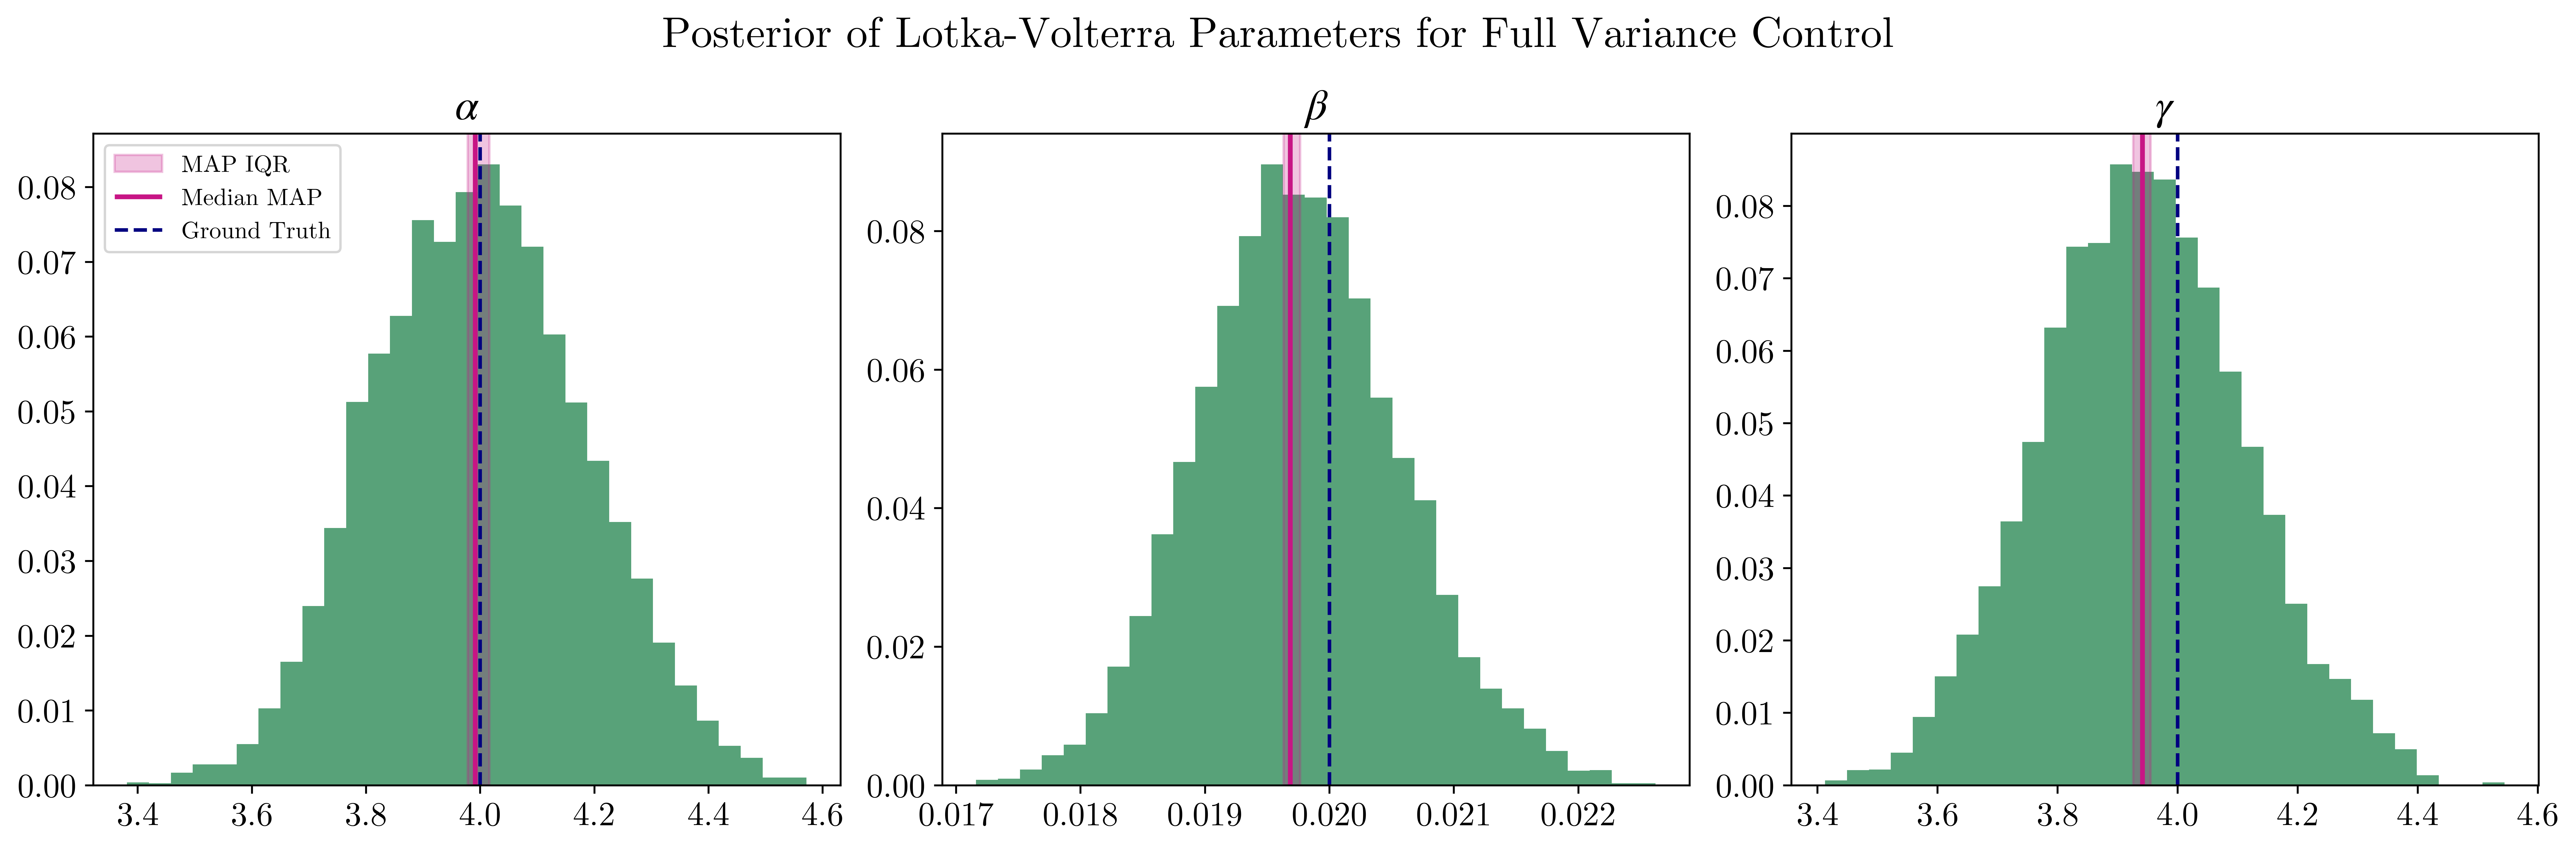

In [57]:
key = (2, None, 1.0)

lvp = lv_fvc_posterior[key]
lvw = lv_fvc_weights[key]
lv_info = lv_fvc_hdpr[key]

#Pool the data
# lvp_pooled = 
print(np.array(lvp).shape)
lvp_pooled = np.array(lvp).reshape(-1,3)
lvw_pooled = np.array(lvw).reshape(-1)/10
lv_maps = np.array([lv_info[i][0] for i in range(10)])
lv_map_med = np.median(lv_maps,axis = 0)
lv_map_lower = np.quantile(lv_maps,0.25,axis=0)
lv_map_upper = np.quantile(lv_maps,0.75,axis=0)

print(lvp_pooled.shape)
print(lvw_pooled.shape)

def mix_colors(color1, color2, w=0.5):
    """
    Return a convex combination of two colors.
    w = weight for color1 (between 0 and 1)
    """
    c1 = np.array(mcolors.to_rgb(color1))
    c2 = np.array(mcolors.to_rgb(color2))
    mixed = (1 - w) * c1 + w * c2
    return mcolors.to_hex(mixed)

hist_color = mix_colors('seagreen', 'white', 0.2)      # muted gray-blue, recedes
map_color  = 'mediumvioletred'      # magenta — auto-selection signal
true_color = 'navy'      # charcoal-lavender, unchanged

titles = [r'$\alpha$',r'$\beta$',r'$\gamma$']
gt_values = [4,0.02,4]

fig,ax = plt.subplots(1,3,figsize=(15,5))
for i in range(3):
    ax[i].hist(lvp_pooled[:,i], weights=lvw_pooled, bins=int(np.sqrt(1000)),
               color=hist_color, density=False)
    ax[i].set_title(titles[i], fontsize=18)

    ymin, ymax = ax[i].get_ylim()

    # IQR band for the MAP across 10 replicates
    ax[i].axvspan(lv_map_lower[i], lv_map_upper[i], color=map_color, alpha=0.25,
                  label='MAP IQR')
    # Median MAP
    ax[i].vlines(lv_map_med[i], ymin, ymax, color=map_color, lw=2, label='Median MAP')
    # Ground truth
    ax[i].vlines(gt_values[i], ymin, ymax, color=true_color, lw=1.5, ls='--', label='Ground Truth')

    ax[i].set_ylim(ymin, ymax)

ax[0].legend(fontsize=10, loc = 'upper left')
plt.suptitle('Posterior of Lotka-Volterra Parameters for Full Variance Control', fontsize=18)
plt.tight_layout()

# titles = [r'$\alpha$',r'$\beta$',r'$\gamma$']
# gt_values = [4,0.02,4]

# fig,ax = plt.subplots(1,3,figsize=(15,5))
# for i in range(3):
#     ax[i].hist(lvp_pooled[:,i],weights = lvw_pooled,bins = int(np.sqrt(1000)),color = 'seagreen')
#     ax[i].set_title(titles[i],fontsize = 18)
#     ymin,ymax = ax[i].get_ylim()
#     ax[i].vlines(gt_values[i],ymin,ymax,color = 'blue')
#     ax[i].set_ylim(ymin,ymax)
